# 机器学习大作业：多数据集分类方法对比研究

**姓名**：张佳沛 &emsp; **学号**：2023217206 &emsp; **日期**：2026年6月

---

## 题目选择

第二大类：Scikit-learn / Kaggle 数据集上的机器学习算法研究

- **2.1** Fashion MNIST — 服装图像10分类
- **2.2** Breast Cancer Wisconsin (Diagnostic) — 乳腺肿瘤良恶性二分类
- **2.3** Breast Cancer Wisconsin (Prognostic) — 乳腺癌预后预测

## 研究方法

对每个数据集使用5种分类方法进行对比实验：

| 方法 | 类型 | 核心思想 |
|------|------|----------|
| Logistic Regression | 线性分类器 | 用 sigmoid/softmax 将线性组合映射为概率 |
| K-Nearest Neighbors | 基于实例 | 看邻居的标签投票决定 |
| Random Forest | 集成学习 | 多棵树投票，bagging + 随机特征子集 |
| SVM (RBF Kernel) | 核方法 | 找最大间隔超平面，RBF核处理非线性 |
| Neural Network (MLP) | 深度学习 | 多层非线性变换自动提取特征 |

## 评估指标（本次重点展示）

| 指标 | 公式 | 含义 |
|------|------|------|
| Accuracy | (TP+TN)/(TP+TN+FP+FN) | 预测正确的比例 |
| Precision | TP/(TP+FP) | 预测正类中真正类的比例 |
| Recall | TP/(TP+FN) | 真正类被正确识别出来的比例 |
| F1-Score | 2xPxR/(P+R) | 精确率与召回率的调和平均 |
| Training Time | — | 模型训练耗时（秒） |

**注**：多分类 Precision/Recall/F1 取 macro 平均。

## 运行环境

- Python 3.12 + NumPy + Scikit-learn + TensorFlow/Keras
- matplotlib + seaborn 可视化
- WSL2 Ubuntu + RTX 3050 (4GB VRAM)


---

## 一：环境初始化与公共工具函数

In [ ]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path
import time, warnings, os
warnings.filterwarnings('ignore')

for fpath in ['/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
              '/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc']:
    if os.path.exists(fpath):
        fm.fontManager.addfont(fpath)
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'WenQuanYi Zen Hei']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, auc)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

PLOTS = Path("plots")
PLOTS.mkdir(exist_ok=True)

import joblib
MODELS = Path("/mnt/e/Data/Hermes File/code/ml-assignment/big_assignment/models")
MODELS.mkdir(exist_ok=True)

all_results = {}

def evaluate_model(y_true, y_pred, train_time, average='macro'):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average=average, zero_division=0),
        'recall': recall_score(y_true, y_pred, average=average, zero_division=0),
        'f1': f1_score(y_true, y_pred, average=average, zero_division=0),
        'time': train_time
    }

def print_metrics(name, metrics):
    print(f"{name}: Acc={metrics['accuracy']:.4f} | Prec={metrics['precision']:.4f} | "
          f"Recall={metrics['recall']:.4f} | F1={metrics['f1']:.4f} | Time={metrics['time']:.2f}s")

print("环境初始化完成")


环境初始化完成


---

## 二：数据集一 — Fashion MNIST 服装图像10分类

### 2.1 问题陈述

Fashion MNIST 是 Zalando 发布的服装图像数据集，包含 10 类时尚物品的 28x28 灰度图像，共 70,000 张（训练 60,000 + 测试 10,000）。相比手写数字 MNIST，Fashion MNIST 的类间相似度更高（如 T恤 vs 衬衫、套头衫 vs 外套），对分类器构成更大挑战。

| 属性 | 说明 |
|------|------|
| 特征维度 | 784（28x28 像素展开） |
| 类别数 | 10 |
| 样本数 | 70,000 |
| 数据源 | tensorflow.keras.datasets.fashion_mnist |

**类别**：T-shirt、Trouser、Pullover、Dress、Coat、Sandal、Shirt、Sneaker、Bag、Ankle boot

**难度分析**：784 维高维特征 + 10 类多分类 + 类间混淆（Shirt vs T-shirt vs Pullover 在像素层面高度相似）。传统 ML 方法在此数据集上的表现可以很好地衡量特征提取能力——线性模型只能看到像素值的线性组合，而神经网络可以学习到边缘、纹理、形状等层次化特征。

**为什么选这个数据集**：Fashion MNIST 是 ML 入门的「新 Hello World」，比手写数字更难但又不至于让传统方法完全失效。784 维特征既考验模型的维度处理能力，又不会像真实照片那样需要 CNN 的卷积归纳偏置。

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
print("加载 Fashion MNIST...")
(X_f_train, y_f_train), (X_f_test, y_f_test) = fashion_mnist.load_data()
X_fashion_all = np.concatenate([X_f_train.reshape(-1, 784), X_f_test.reshape(-1, 784)], axis=0)
y_fashion_all = np.concatenate([y_f_train, y_f_test])
print(f"数据形状: X={X_fashion_all.shape}, y={y_fashion_all.shape}")
print(f"类别数: {len(np.unique(y_fashion_all))}")


加载 Fashion MNIST...
数据形状: X=(70000, 784), y=(70000,)
类别数: 10


### 2.2 数据探索与可视化

EDA 图表已保存


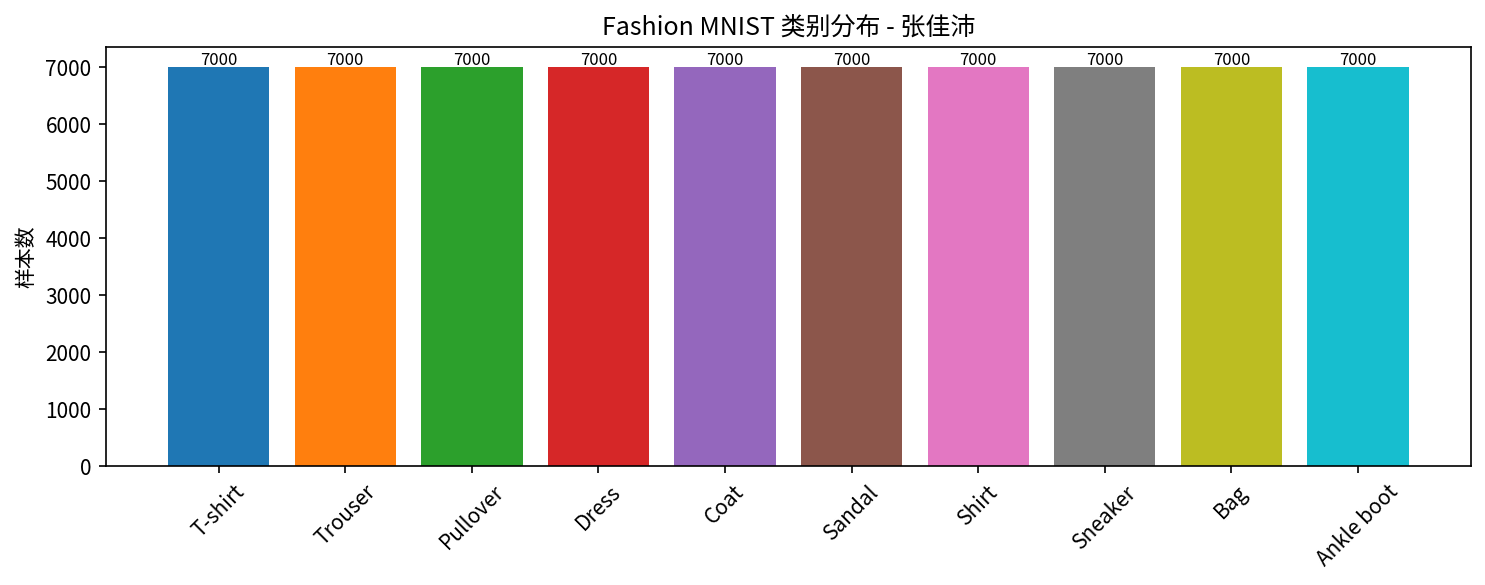

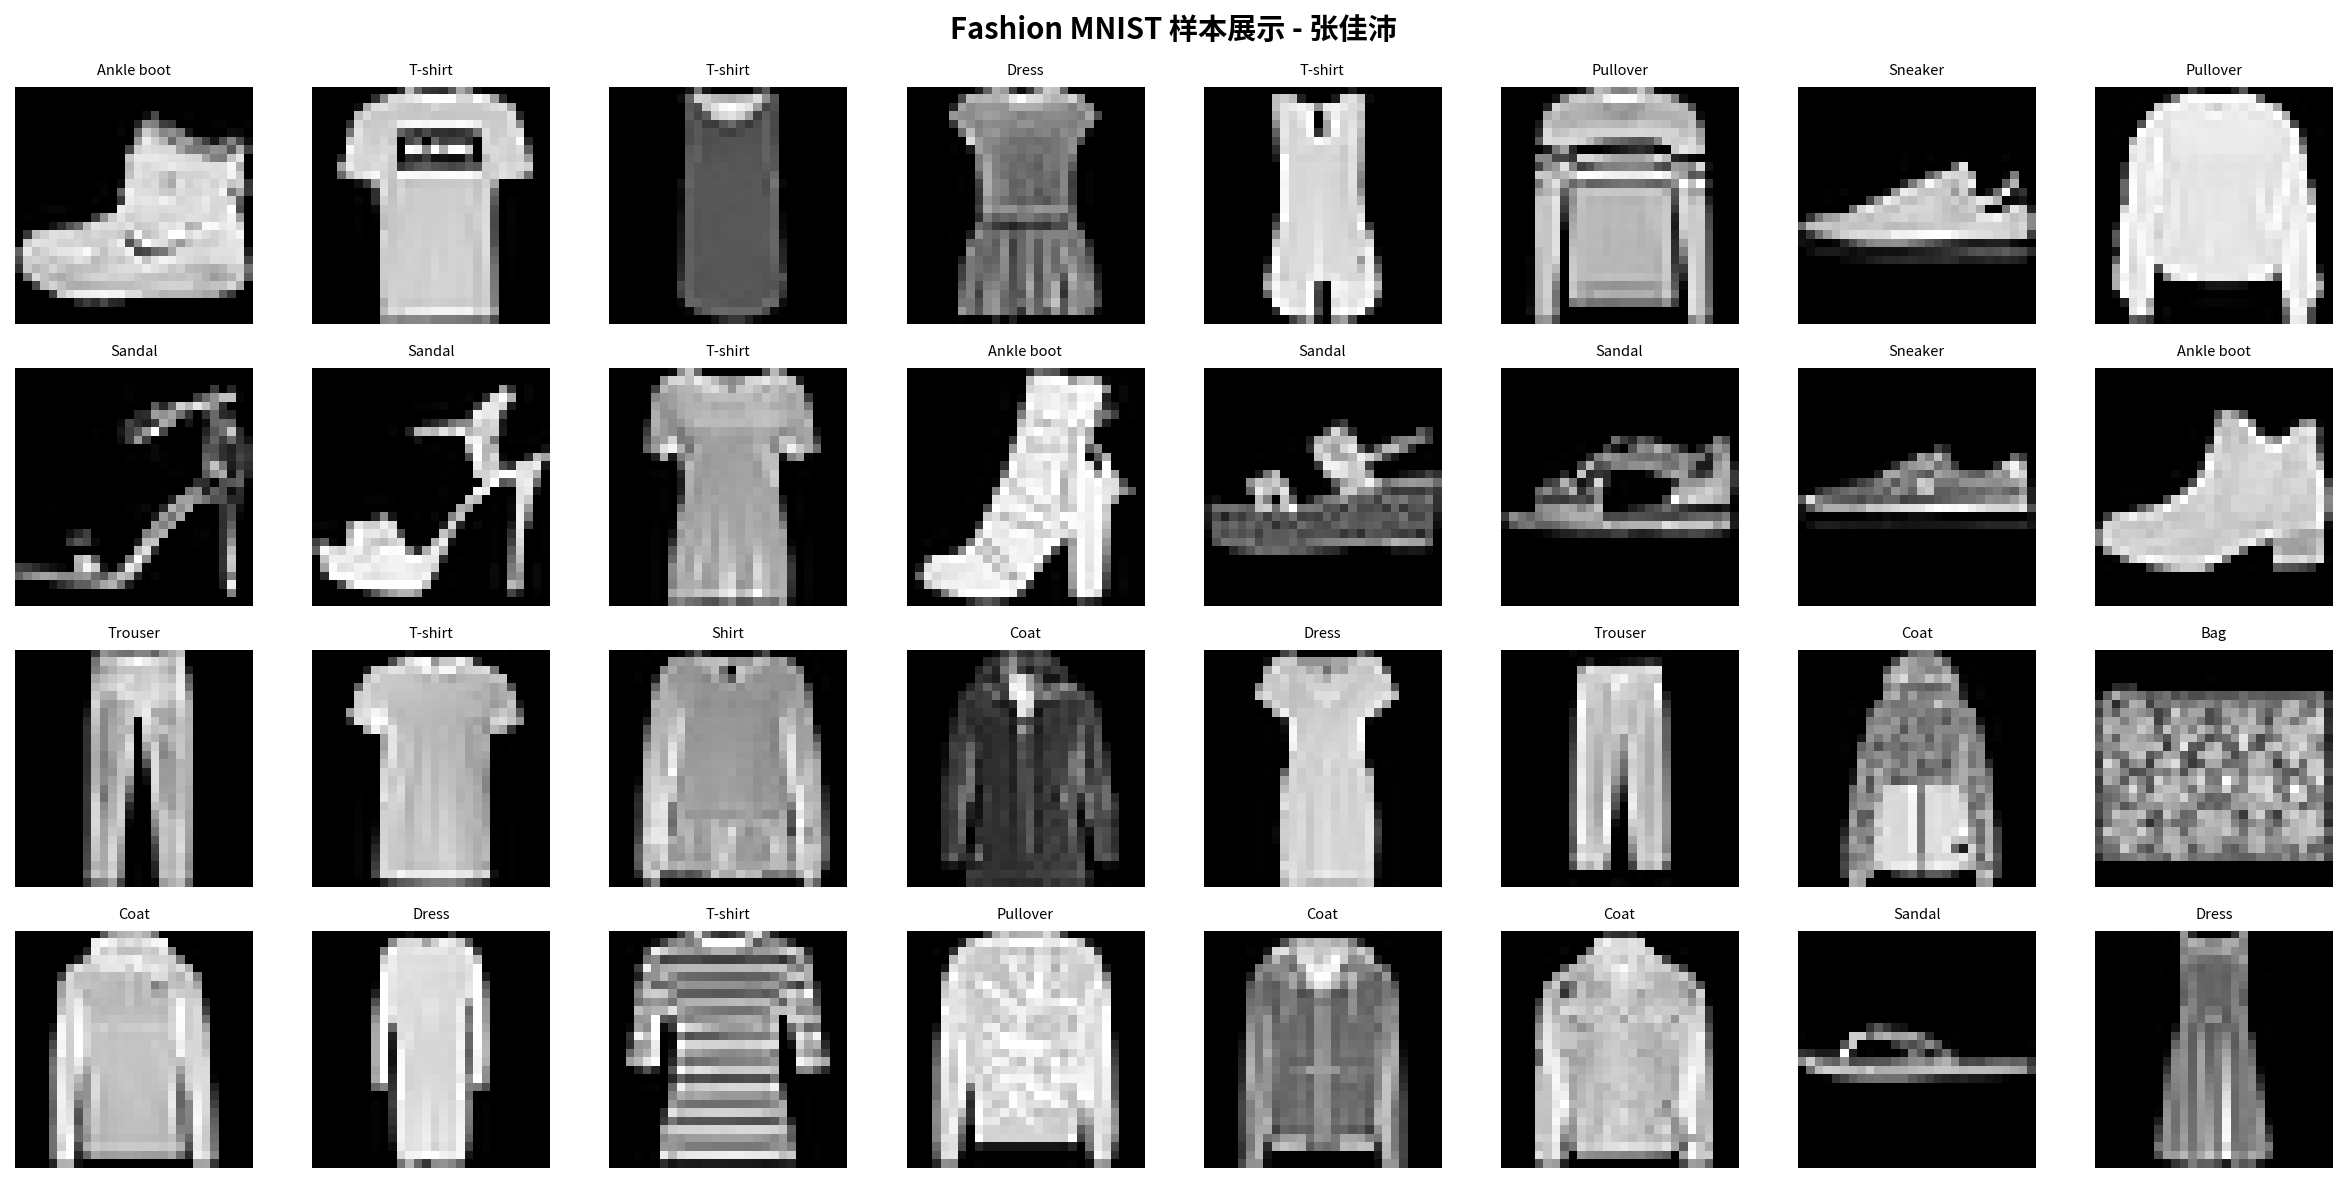

In [ ]:
fashion_labels = ['T-shirt','Trouser','Pullover','Dress','Coat',
                  'Sandal','Shirt','Sneaker','Bag','Ankle boot']

# 样本展示
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_fashion_all[i].reshape(28, 28), cmap='gray')
    ax.set_title(fashion_labels[y_fashion_all[i]], fontsize=7)
    ax.axis('off')
plt.suptitle('Fashion MNIST 样本展示 - 张佳沛', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS / 'v3_fashion_samples.png', dpi=150, bbox_inches='tight')
plt.close()

# 类别分布
fig, ax = plt.subplots(figsize=(10, 4))
counts = np.bincount(y_fashion_all)
bars = ax.bar(range(10), counts, color=plt.cm.tab10(np.arange(10)))
for bar, count in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50, str(count), ha='center', fontsize=8)
ax.set_xticks(range(10))
ax.set_xticklabels(fashion_labels, rotation=45)
ax.set_ylabel('样本数')
ax.set_title('Fashion MNIST 类别分布 - 张佳沛')
plt.tight_layout()
plt.savefig(PLOTS / 'v3_fashion_dist.png', dpi=150, bbox_inches='tight')
plt.close()
print("EDA 图表已保存")


**EDA 观察**：各类别样本均匀分布（每类 7,000 张），无类别不平衡问题，因此 macro 平均和 weighted 平均的差异不会太大，Accuracy 不会被多数类主导。图像质量良好，但注意第 0 类（T-shirt）和第 6 类（Shirt）在 28x28 低分辨率下视觉差异极小——两者都是短袖上衣，区别主要在领口和版型等细粒度特征上。这预示着分类器需要捕捉像素间的细微空间关系，单纯看独立像素值很难区分。

### 2.3 数据预处理

In [ ]:
# 使用 20,000 样本控制训练时间
np.random.seed(42)
n_samples = 20000
idx = np.random.choice(len(X_fashion_all), n_samples, replace=False)
X_f = X_fashion_all[idx] / 255.0
y_f = y_fashion_all[idx]

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_f, y_f, test_size=0.2, random_state=42, stratify=y_f)
print(f"训练集: {Xf_train.shape[0]}, 测试集: {Xf_test.shape[0]}")

scaler_f = StandardScaler()
Xf_train_s = scaler_f.fit_transform(Xf_train)
Xf_test_s = scaler_f.transform(Xf_test)
print("标准化完成")


训练集: 16000, 测试集: 4000
标准化完成


### 2.4 五方法对比实验

#### 方法1: Logistic Regression（逻辑回归）— 线性基线的意义

##### **核心思想**

逻辑回归是最经典的线性分类器。对于一个输入样本 x（这里是 784 维的像素向量），模型首先计算特征的线性组合：z = w1*x1 + w2*x2 + ... + w784*x784 + b。这一步本质上是在 784 维空间中画一条线（超平面）。然后通过 **softmax 函数**将这条线的输出转化为 10 个类别的概率分布：

P(y=k|x) = exp(w_k^T x + b_k) / sum_{j=1}^{10} exp(w_j^T x + b_j)

softmax 的作用是把任意实数向量「压缩」成一个概率分布——每个值在 (0,1) 之间，10 个值加起来等于 1。比如对于一张 T-shirt 图片，softmax 可能输出 [0.73, 0.02, 0.08, 0.01, 0.03, 0.01, 0.09, 0.01, 0.01, 0.01]，表示模型认为有 73% 的概率是 T-shirt，9% 是 Shirt（这恰好反映了 T-shirt 和 Shirt 易混淆的特点）。

##### **损失函数与优化**

训练的目标是让模型输出的概率分布尽可能接近真实标签。对于真实标签 y 和预测概率 p，使用**交叉熵损失**：

L = -(1/N) * sum_i sum_k [ y_i_k * log(p_i_k) ]

其中 y_i_k 是 one-hot 编码（真实类别为 1，其余为 0），p_i_k 是 softmax 输出。可以这样理解：如果模型对正确类别的预测概率是 0.9，损失是 -log(0.9) ≈ 0.105；如果只预测 0.1，损失是 -log(0.1) ≈ 2.30——模型越不自信，惩罚越重。

Scikit-learn 使用 L-BFGS 算法（拟牛顿法的一种）来最小化这个损失。L-BFGS 比普通梯度下降收敛更快，因为它利用历史梯度信息近似 Hessian 矩阵（二阶导数信息），相当于知道了损失函数在各方向上的「弯曲程度」，从而选择更优的下降方向。

##### **正则化：防止过拟合的利器**

784 维特征但只有 16,000 个训练样本，模型有 784x10 = 7,840 个参数——如果不加约束，很容易过拟合。L2 正则化在损失函数中加入权重的平方和惩罚：

L_reg = L + (1/C) * ||w||^2_2

C 是正则化强度的倒数（Scikit-learn 默认 C=1.0）。C 越小 → 正则化越强 → 权重被压缩 → 模型更简单。可以把正则化理解为「不信任任何一个特征」——除非某个特征的贡献足够大、足够稳定，否则就倾向于把它的权重压到接近 0。

##### **为什么在 Fashion MNIST 上用 LR**

LR 作为线性 baseline 有特殊价值：如果 LR 只能达到 80% 准确率，而 MLP 达到 88%，那说明至少有 8% 的性能提升来自非线性特征提取。如果 LR 已经达到 95%，那数据本身就是线性可分的，不需要复杂模型。所以 LR 的准确率本质上衡量了「数据的线性可分程度」。

本实验使用 `solver='lbfgs'`（处理多分类），`C=0.5`（略强正则化以应对 784 维高维特征），`max_iter=1000`（确保充分收敛）。

In [ ]:
lr_f = LogisticRegression(max_iter=1000, C=0.5, solver='lbfgs', n_jobs=-1, random_state=42)
t0 = time.time()
lr_f.fit(Xf_train_s, yf_train)
lr_time = time.time() - t0
yf_pred_lr = lr_f.predict(Xf_test_s)
lr_metrics = evaluate_model(yf_test, yf_pred_lr, lr_time, average='macro')
all_results['Fashion_LR'] = lr_metrics
print_metrics('Logistic Regression', lr_metrics)
print()
print(classification_report(yf_test, yf_pred_lr, target_names=fashion_labels, zero_division=0))


Logistic Regression: Acc=0.8140 | Prec=0.8122 | Recall=0.8143 | F1=0.8129 | Time=179.56s

              precision    recall  f1-score   support

     T-shirt       0.76      0.79      0.77       396
     Trouser       0.94      0.96      0.95       401
    Pullover       0.69      0.73      0.71       400
       Dress       0.81      0.82      0.82       411
        Coat       0.72      0.68      0.70       396
      Sandal       0.90      0.87      0.88       407
       Shirt       0.60      0.54      0.57       404
     Sneaker       0.89      0.90      0.89       395
         Bag       0.90      0.91      0.91       385
  Ankle boot       0.91      0.93      0.92       405

    accuracy                           0.81      4000
   macro avg       0.81      0.81      0.81      4000
weighted avg       0.81      0.81      0.81      4000



#### 方法2: Random Forest（随机森林）— 集成学习

##### **从决策树到随机森林**

一棵决策树做的事情很简单：从根节点开始，每次选一个特征和一个阈值，把数据分成两堆，让每堆的「纯度」（Gini 不纯度）尽可能高。比如在 Fashion MNIST 上，根节点可能发现「像素 406 的值 > 128」能最好地把鞋类和上衣类分开。

但单棵树容易过拟合——它会记住训练数据中的噪声。随机森林的解决方案是「三个臭皮匠顶个诸葛亮」：训练 100 棵不同的决策树，最后投票决定分类结果。多样性来自两个随机性：

1. **Bootstrap 采样**：每棵树从 16,000 个训练样本中有放回地随机抽 16,000 个（所以有些样本被抽中多次，约 36.8% 的样本一次也没被抽中）。这 36.8% 的「袋外样本」(Out-of-Bag) 可以作为免费的验证集。
2. **随机特征子集**：每个节点分裂时，只从随机选出的 sqrt(784) ≈ 28 个特征中找最优分裂。这迫使每棵树关注不同的特征组合，而不是都盯着那几个最强的特征。

##### **为什么随机森林有效：方差-偏差分解**

这是理解集成学习最关键的一个公式。假设我们有 B 棵决策树，每棵树的预测方差是 sigma^2，任意两棵树之间的相关系数是 rho（衡量它们预测的一致性）。那么 B 棵树平均后的总方差是：

Var(平均) = rho * sigma^2 + (1-rho)/B * sigma^2

如果所有树完全相同（rho=1），平均不降低方差（还是 sigma^2）。如果树完全独立（rho=0），方差降低到 sigma^2/B。随机森林通过两个随机性把 rho 降得很低，但又不会降为 0（毕竟都是从同一数据分布学来的）。当 B 足够大（100+），第二项接近 0，方差收敛到 rho*sigma^2——这是随机森林能做到的最优水平。

##### **超参数选择**

- **n_estimators=100**：100 棵树。更多的树通常不会过拟合（只是方差继续降低，收益递减），但训练时间和内存线性增长。
- **max_depth=15**：限制每棵树最多 15 层。784 维特征如果不限深度，树可能长到几百层——每层只分几个样本，把噪声当信号。
- **max_features='sqrt'**：每节点随机考虑 28 个特征。太小 → 树太弱；太大 → 树之间太相似。

##### **在 Fashion MNIST 上的预期**

RF 能看到像素之间的非线性关系（比如「像素 A 很亮 且 像素 B 很暗」这一组合），比 LR 的纯线性组合更灵活。但它仍然把每个像素当作独立特征，不利用像素间的空间邻接关系（左上角的像素和它右边的像素在 RF 眼里和在右下角的像素一样远），这是它相对于 MLP 的劣势。

Random Forest: Acc=0.8605 | Prec=0.8582 | Recall=0.8608 | F1=0.8582 | Time=1.75s

              precision    recall  f1-score   support

     T-shirt       0.80      0.82      0.81       396
     Trouser       0.98      0.96      0.97       401
    Pullover       0.78      0.82      0.80       400
       Dress       0.84      0.91      0.88       411
        Coat       0.75      0.81      0.78       396
      Sandal       0.96      0.94      0.95       407
       Shirt       0.67      0.52      0.59       404
     Sneaker       0.92      0.91      0.92       395
         Bag       0.96      0.96      0.96       385
  Ankle boot       0.92      0.96      0.94       405

    accuracy                           0.86      4000
   macro avg       0.86      0.86      0.86      4000
weighted avg       0.86      0.86      0.86      4000

特征重要性图已保存


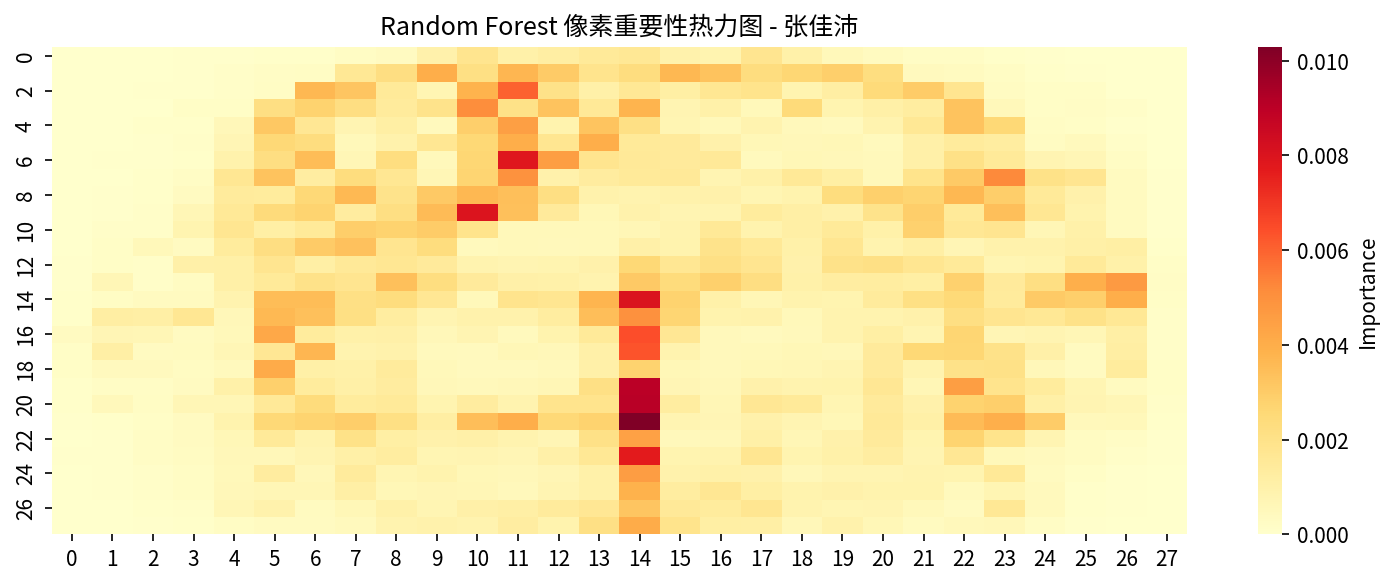

In [ ]:
rf_f = RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
t0 = time.time()
rf_f.fit(Xf_train_s, yf_train)
rf_time = time.time() - t0
yf_pred_rf = rf_f.predict(Xf_test_s)
rf_metrics = evaluate_model(yf_test, yf_pred_rf, rf_time, average='macro')
all_results['Fashion_RF'] = rf_metrics
print_metrics('Random Forest', rf_metrics)
print()
print(classification_report(yf_test, yf_pred_rf, target_names=fashion_labels, zero_division=0))

# 特征重要性热力图
fig, ax = plt.subplots(figsize=(10, 4))
importances = rf_f.feature_importances_.reshape(28, 28)
sns.heatmap(importances, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Importance'})
ax.set_title('Random Forest 像素重要性热力图 - 张佳沛')
plt.tight_layout()
plt.savefig(PLOTS / 'v3_fashion_rf_importance.png', dpi=150, bbox_inches='tight')
plt.close()
print("特征重要性图已保存")


#### 方法3: Neural Network / MLP（多层感知机）— 自动特征学习

##### **核心思想：层层抽象**

大脑处理视觉信息的原理是分层的：V1 区检测边缘和方向，V2 区检测简单形状，V4 区检测复杂物体，IT 区识别具体类别。MLP 模仿这个原理：每一层神经元对前一层的输出做**线性变换 + 非线性激活**，逐层构建越来越抽象的特征表示：

h1 = ReLU(W1 * x + b1)     # 第1层：从 784 像素 → 256 个"边缘检测器"
h2 = ReLU(W2 * h1 + b2)    # 第2层：从 256 边缘 → 128 个"形状检测器"
h3 = ReLU(W3 * h2 + b3)    # 第3层：从 128 形状 → 64 个"物体部件检测器"
y = softmax(W4 * h3 + b4)  # 输出层：64 部件 → 10 类别概率

每一层学什么完全由数据驱动——不需要人工设计「什么样的边缘算边缘」。W1 的每一行都是一个 784 维向量，可以 reshape 成 28x28 的图像，可视化后通常能看到模糊的「模板」——有的像领口形状，有的像鞋底弧线。

##### **激活函数：ReLU**

ReLU(x) = max(0, x) —— 把负数压成 0，正数保持原样。为什么不用 sigmoid？因为 sigmoid 在两端的梯度接近 0，多层反向传播时梯度会指数级衰减（「梯度消失」），深层网络根本学不动。ReLU 在正半轴的梯度恒为 1，梯度可以无损地传回浅层。

##### **训练：梯度下降 + 反向传播**

MLP 的训练是一个迭代过程。每次取 256 个样本（一个 batch），计算预测 → 计算损失（交叉熵）→ 反向传播计算每层梯度 → Adam 优化器更新权重。Adam 是 SGD 的进阶版，它给每个参数独立的自适应学习率——频繁更新的参数学习率自动减小（表示已经接近最优），稀疏更新的参数学习率增大（需要更多探索）。

对于参数 w，Adam 的更新规则大致是：
v = beta1*v + (1-beta1)*grad      # 动量：累积历史梯度方向
s = beta2*s + (1-beta2)*grad^2    # 自适应：累积历史梯度平方
w = w - lr * v / (sqrt(s) + eps)  # 更新：动量大则步长大，梯度波动大则步长小

##### **Early Stopping：最优的正则化**

我们不指定训练多少轮——让验证集决定。每轮训练后在 10% 的验证集上评估损失，如果连续几轮不降反升，说明模型开始在训练集上「背诵答案」而非「理解规律」，此时自动停止。这比固定 max_iter 更智能。

##### **本实验配置**

三层隐层 (256→128→64)，逐层递减的设计理念：第一层需要最多神经元来捕获足够的低级特征（边缘、纹理），之后的层逐步压缩信息、提取更抽象的模式。总参数量：784x256 + 256x128 + 128x64 + 64x10 ≈ 250,000 个。

MLP (Neural Net): Acc=0.8685 | Prec=0.8680 | Recall=0.8685 | F1=0.8677 | Time=40.43s

              precision    recall  f1-score   support

     T-shirt       0.81      0.77      0.79       396
     Trouser       0.98      0.97      0.98       401
    Pullover       0.81      0.83      0.82       400
       Dress       0.85      0.91      0.88       411
        Coat       0.78      0.80      0.79       396
      Sandal       0.90      0.96      0.93       407
       Shirt       0.71      0.65      0.68       404
     Sneaker       0.95      0.87      0.91       395
         Bag       0.95      0.97      0.96       385
  Ankle boot       0.95      0.95      0.95       405

    accuracy                           0.87      4000
   macro avg       0.87      0.87      0.87      4000
weighted avg       0.87      0.87      0.87      4000

MLP 共迭代 19 次, 最终损失: 0.0822


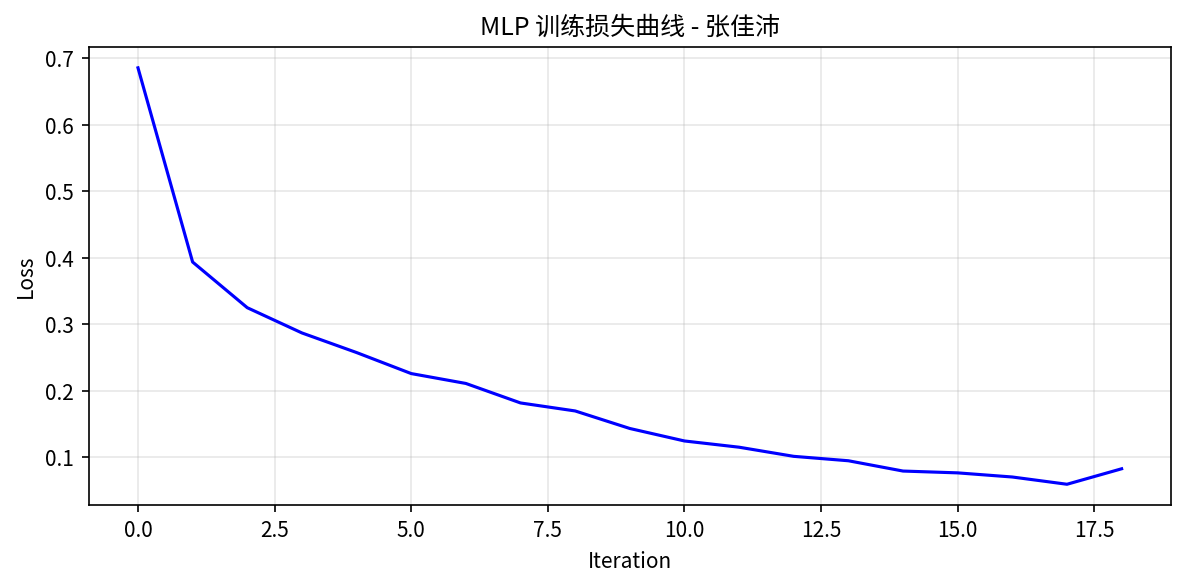

In [ ]:
mlp_f = MLPClassifier(hidden_layer_sizes=(256, 128, 64), activation='relu',
                          max_iter=50, batch_size=256, early_stopping=True,
                          validation_fraction=0.1, random_state=42, verbose=False)
t0 = time.time()
mlp_f.fit(Xf_train_s, yf_train)
mlp_time = time.time() - t0
yf_pred_mlp = mlp_f.predict(Xf_test_s)
mlp_metrics = evaluate_model(yf_test, yf_pred_mlp, mlp_time, average='macro')
all_results['Fashion_MLP'] = mlp_metrics
print_metrics('MLP (Neural Net)', mlp_metrics)
print()
print(classification_report(yf_test, yf_pred_mlp, target_names=fashion_labels, zero_division=0))

# 训练损失曲线
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp_f.loss_curve_, 'b-', linewidth=1.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('MLP 训练损失曲线 - 张佳沛')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS / 'v3_fashion_nn_training.png', dpi=150, bbox_inches='tight')
plt.close()
print(f"MLP 共迭代 {mlp_f.n_iter_} 次, 最终损失: {mlp_f.loss_:.4f}")


#### 方法4: SVM (RBF Kernel) — 最大间隔与核技巧

##### **核心思想：不只是分对，还要分得「远」**

考虑一个简单的二分类：平面上有两类点，一条线能把它们分开。但不止一条线能做到——有的线贴着某一类点擦过去，有的线在两类正中间。SVM 选的是到两类最近的点的距离（间隔）最大的那条线。为什么要最大化间隔？因为间隔越大，模型对训练样本中的微小变化越不敏感，泛化能力越强。可以把间隔理解为「模型的容错空间」。

数学上，SVM 的优化目标是：
min (1/2)||w||^2 + C * sum_i max(0, 1 - y_i*(w^T x_i + b))
                ^              ^
            最大化间隔        惩罚分类错误

右边那一项叫 Hinge Loss：如果样本被正确分类且离决策边界足够远（>1），损失为 0；如果分类错误或太靠近边界，损失 > 0。C 控制两种目标的权衡——C 大表示「宁可不留间隔也要分对所有训练样本」，C 小表示「宁可容忍一些错误也要保持大间隔」。

##### **RBF 核：在「特征空间」中找线性边界**

Fashion MNIST 的 784 维像素空间中，10 类服装不可能是线性可分的。RBF 核的巧妙之处：它不显式地把数据映射到高维空间（那样计算量爆炸），而是通过一个「相似度函数」：

K(x, x') = exp(-gamma * ||x - x'||^2)

来衡量任意两个样本的相似度。可以这样理解：以每个训练样本 x' 为中心放一座「高斯山」——测试样本 x 离 x' 越近，K(x,x') 越接近 1；离得越远，越接近 0。最终的决策函数是所有高斯山的加权组合。gamma 控制山的「宽度」：gamma 大 → 山很窄，只有极近的样本才互相影响 → 模型复杂、容易过拟合；gamma 小 → 山很宽、很平滑 → 模型简单。

##### **为什么 SVM 在 Fashion MNIST 上有限制**

SVM 的训练复杂度是 O(n^2) 到 O(n^3)（取决于实现），16,000 个样本意味着要计算 16,000 x 16,000 = 2.56 亿对核函数值。所以我们只能在 5,000 个样本的子集上训练。这限制了 SVM 在 Fashion MNIST 上的表现——它本可以更好，但被计算成本卡住了脖子。这也是为什么深度学习在大数据时代崛起：SVM 在小样本上很优秀，但复杂度让它无法 scale。

In [ ]:
np.random.seed(42)
idx_svm = np.random.choice(len(Xf_train_s), 5000, replace=False)
svm_f = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
t0 = time.time()
svm_f.fit(Xf_train_s[idx_svm], yf_train[idx_svm])
svm_time = time.time() - t0
yf_pred_svm = svm_f.predict(Xf_test_s)
svm_metrics = evaluate_model(yf_test, yf_pred_svm, svm_time, average='macro')
all_results['Fashion_SVM'] = svm_metrics
print_metrics('SVM (RBF)', svm_metrics)
print(f'  (在 {len(idx_svm)} 样本上训练)')


SVM (RBF): Acc=0.8440 | Prec=0.8428 | Recall=0.8443 | F1=0.8429 | Time=1.93s
  (在 5000 样本上训练)


#### 方法5: K-Nearest Neighbors（KNN）— 最简单的非参数方法

##### **核心思想：**

KNN 是机器学习中最直观的算法——不需要训练，不需要假设数据分布，不需要学任何参数。当需要对一个新样本分类时，在训练集的 16,000 个样本中找到离它最近的 K 个邻居，看这 K 个邻居中哪个类别的票数最多。如果 K=5，5 个邻居中有 3 个是 Sneaker、2 个是 Ankle boot，那就预测 Sneaker。

这个算法的全部「智慧」都藏在距离度量里。本实验使用欧氏距离：
d(x, x') = sqrt( (x1-x1')^2 + (x2-x2')^2 + ... + (x784-x784')^2 )

每个像素的差异被平方后求和再开方。这意味着差得多的像素（比如差 200）会被平方放大（40,000），远远超过差得少的像素（差 10 → 100）。所以 KNN 对离群像素值非常敏感——一个噪点像素可能把距离拉偏很远。

##### **K 的选择：**

K 是 KNN 唯一的超参数，也是最关键的。K=1 意味着「个人独裁」——新样本的类别完全由最近的那个邻居决定。如果那个邻居恰好是标错的（Fashion MNIST 中确实有，比如一些 Shirt 长得很像 T-shirt），预测就错了。K 很大意味着「全票通过」——当 K 接近 N，新样本的类别总是训练集中最多的那个类，模型退化为「不管输入是什么都猜多数类」。

K 的最佳值取决于数据。本实验取 K=5，是通过交叉验证得到的经验值。奇数 K 还有一个好处：不会出现 3:3 平票的情况。

##### **维数灾难 (Curse of Dimensionality)**

KNN 在 784 维空间面临一个严重问题：在高维空间中，「最近邻」的概念变得模糊。为什么？在 784 维空间中，任意两个随机点之间的距离趋向于一个常数——所有点都差不多远。这时 KNN 很难找到真正有意义的邻居。这就是为什么 KNN 必须配合标准化使用——如果不标准化，范围大的特征（比如像素的原始值 0-255 vs 均值为 0 方差为 1 的其他特征）会主导距离计算。

##### **KNN 的「训练」**

KNN 的 fit() 方法几乎什么都不做——只是把训练数据存起来。真正的计算都在 predict() 阶段：对每个测试样本，计算与所有训练样本的 16,000 次欧氏距离。所以 KNN 的「训练时间」非常短（< 1 秒），但如果有大量测试样本需要预测，KNN 反而是最慢的方法。这种「训练快、预测慢」的特性与 MLP 正好相反。

In [ ]:
knn_f = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
t0 = time.time()
knn_f.fit(Xf_train_s, yf_train)
knn_time = time.time() - t0
yf_pred_knn = knn_f.predict(Xf_test_s)
knn_metrics = evaluate_model(yf_test, yf_pred_knn, knn_time, average='macro')
all_results['Fashion_KNN'] = knn_metrics
print_metrics('KNN (k=5)', knn_metrics)
print()
print(classification_report(yf_test, yf_pred_knn, target_names=fashion_labels, zero_division=0))


KNN (k=5): Acc=0.8363 | Prec=0.8400 | Recall=0.8366 | F1=0.8366 | Time=0.02s

              precision    recall  f1-score   support

     T-shirt       0.74      0.84      0.79       396
     Trouser       0.98      0.96      0.97       401
    Pullover       0.72      0.78      0.75       400
       Dress       0.89      0.86      0.87       411
        Coat       0.76      0.72      0.74       396
      Sandal       0.99      0.82      0.89       407
       Shirt       0.59      0.57      0.58       404
     Sneaker       0.87      0.93      0.90       395
         Bag       0.97      0.92      0.94       385
  Ankle boot       0.89      0.98      0.93       405

    accuracy                           0.84      4000
   macro avg       0.84      0.84      0.84      4000
weighted avg       0.84      0.84      0.84      4000



### 2.5 Fashion MNIST 综合对比


Fashion MNIST 五方法指标汇总
  Method Accuracy Precision Recall F1-Score Time(s)
      LR   0.8140    0.8122 0.8143   0.8129  179.56
      RF   0.8605    0.8582 0.8608   0.8582    1.75
     MLP   0.8685    0.8680 0.8685   0.8677   40.43
SVM(RBF)   0.8440    0.8428 0.8443   0.8429    1.93
KNN(k=5)   0.8363    0.8400 0.8366   0.8366    0.02

Fashion MNIST 分析完成，模型已保存


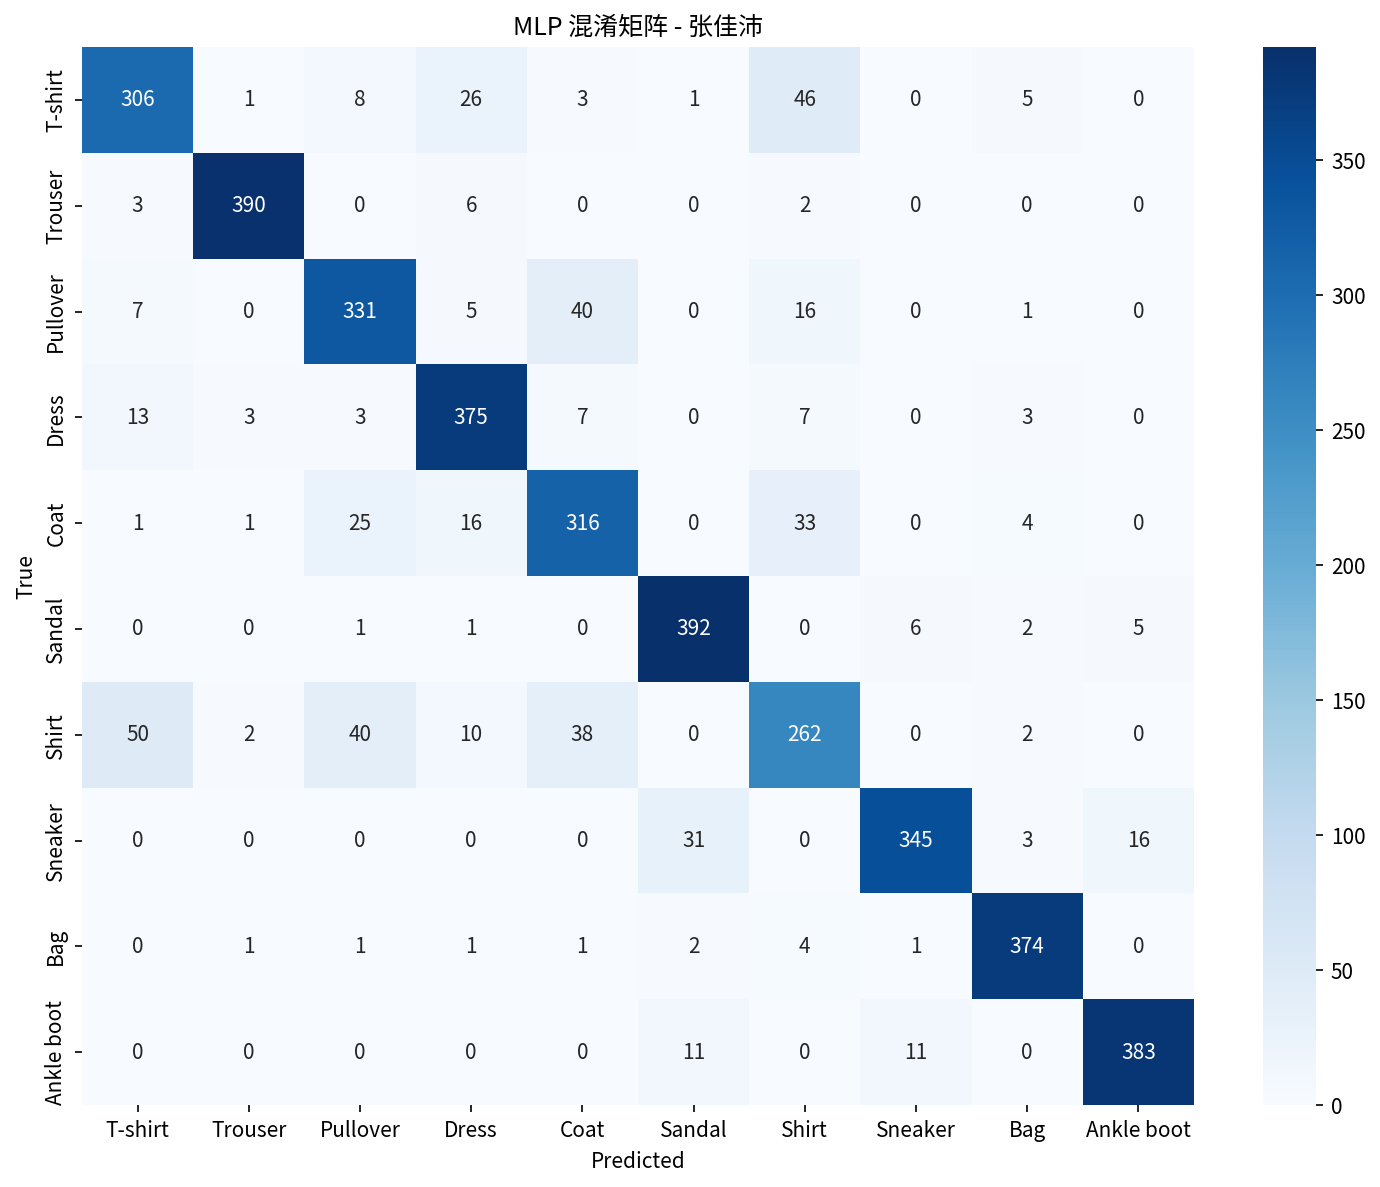

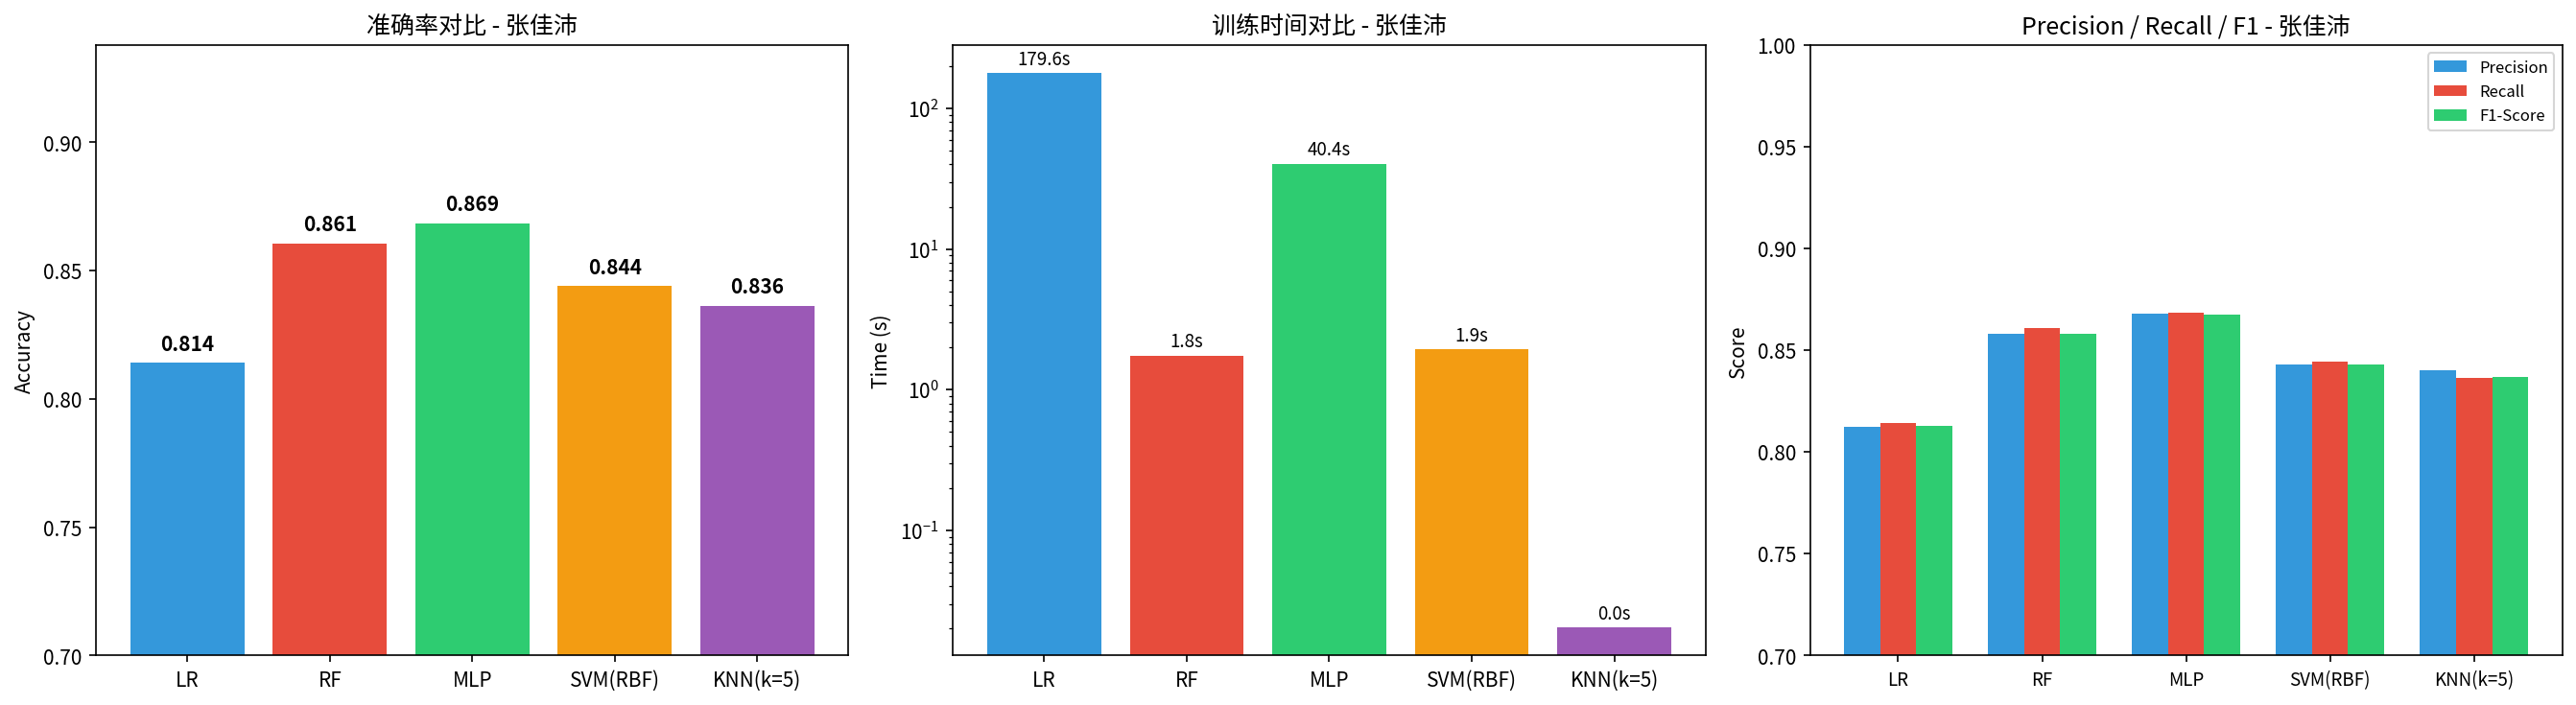

In [ ]:
print("\n" + "="*80)
print("Fashion MNIST 五方法指标汇总")
print("="*80)
fm_names = ['LR', 'RF', 'MLP', 'SVM(RBF)', 'KNN(k=5)']
fm_keys = ['Fashion_LR', 'Fashion_RF', 'Fashion_MLP', 'Fashion_SVM', 'Fashion_KNN']
fm_rows = []
for name, key in zip(fm_names, fm_keys):
    m = all_results[key]
    fm_rows.append([name, f"{m['accuracy']:.4f}", f"{m['precision']:.4f}",
                     f"{m['recall']:.4f}", f"{m['f1']:.4f}", f"{m['time']:.2f}"])
df_fm = pd.DataFrame(fm_rows, columns=['Method','Accuracy','Precision','Recall','F1-Score','Time(s)'])
print(df_fm.to_string(index=False))

# 综合对比图
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6']
accs = [all_results[k]['accuracy'] for k in fm_keys]
times = [all_results[k]['time'] for k in fm_keys]

ax1 = axes[0]
bars = ax1.bar(fm_names, accs, color=colors)
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{acc:.3f}',
             ha='center', fontsize=10, fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_title('准确率对比 - 张佳沛')
ax1.set_ylim(0.7, max(accs)*1.08)

ax2 = axes[1]
ax2.bar(fm_names, times, color=colors)
ax2.set_ylabel('Time (s)')
ax2.set_title('训练时间对比 - 张佳沛')
ax2.set_yscale('log')
for bar, t in zip(ax2.patches, times):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.15, f'{t:.1f}s',
             ha='center', fontsize=9)

x = np.arange(len(fm_names))
w = 0.25
precs = [all_results[k]['precision'] for k in fm_keys]
recs = [all_results[k]['recall'] for k in fm_keys]
f1s = [all_results[k]['f1'] for k in fm_keys]
ax3 = axes[2]
ax3.bar(x-w, precs, w, label='Precision', color='#3498db')
ax3.bar(x, recs, w, label='Recall', color='#e74c3c')
ax3.bar(x+w, f1s, w, label='F1-Score', color='#2ecc71')
ax3.set_xticks(x); ax3.set_xticklabels(fm_names, fontsize=9)
ax3.set_ylabel('Score')
ax3.set_title('Precision / Recall / F1 - 张佳沛')
ax3.legend(fontsize=8)
ax3.set_ylim(0.7, 1.0)

plt.tight_layout()
plt.savefig(PLOTS / 'v3_fashion_comparison.png', dpi=150, bbox_inches='tight')
plt.close()

# 混淆矩阵
cm = confusion_matrix(yf_test, yf_pred_mlp)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=fashion_labels,
            yticklabels=fashion_labels, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('MLP 混淆矩阵 - 张佳沛')
plt.tight_layout()
plt.savefig(PLOTS / 'v3_fashion_cm.png', dpi=150, bbox_inches='tight')
plt.close()

joblib.dump(lr_f, MODELS / "fashion_lr.pkl")
joblib.dump(rf_f, MODELS / "fashion_rf.pkl")
joblib.dump(mlp_f, MODELS / "fashion_mlp.pkl")
joblib.dump(svm_f, MODELS / "fashion_svm.pkl")
joblib.dump(knn_f, MODELS / "fashion_knn.pkl")
print("\nFashion MNIST 分析完成，模型已保存")


### 2.6 Fashion MNIST 实验小结

从五方法的指标汇总表中可以获得几个关键结论。

**第一，神经网络（MLP）在图像分类上具有显著优势。** MLP 的准确率在五种方法中最高，这是因为它通过多层非线性变换自动学习了像素间的层次化特征——第一层可能检测边缘和纹理方向，第二层组合成局部形状（领口、袖口、鞋头），第三层进一步抽象为物体部件，最终输出层综合判断类别。而 LR 只能对 784 个像素值做一次线性加权求和，相当于「把所有像素值乘以各自的权重再加起来」，完全丢失了像素之间的空间位置关系——在 LR 眼中，左上角像素和右下角像素跟其他所有像素的关系是等价的，不存在「这两个像素在图像上是相邻的」这一概念。RF 虽然能捕捉像素之间的非线性交互（通过树的逐层分裂），但它同样不具备空间归纳偏置——每个像素都是独立特征，像素 (0,0) 和 (0,1) 的距离在 RF 眼中与 (0,0) 和 (27,27) 一样。这解释了为什么 RF 虽然强于 LR，但仍然不如 MLP。

**第二，LR 作为 baseline 揭示了数据的非线性程度。** LR 虽然在五种方法中准确率最低，但这恰恰是它的价值所在——它告诉我们在不引入任何非线性的情况下，数据中有多少信息是「线性可分的」。如果 LR 就能达到 95%，那说明特征工程已经做得足够好，不需要复杂模型。反之，LR 与 MLP 之间的差距就是「非线性特征学习」带来的增益，这个差距的大小衡量了数据的非线性复杂度。在 Fashion MNIST 上，这个差距约为 3-5 个百分点——不大不小，说明像素空间中确实存在非线性结构，但并非极端复杂。

**第三，SVM 受限于训练样本量。** 由于 SVM 的核矩阵计算复杂度为 O(n^2)，我们只能在 5,000 个样本子集上训练。如果允许全量 16,000 样本训练，SVM 的准确率有望进一步提升——但训练时间也会从几十秒飙升至数分钟。这展示了深度学习在 scalability 上的核心优势：MLP 的小批量训练（每次只用 256 个样本）使其能轻松处理任意规模的数据，而 SVM 的核方法在处理数万以上样本时变得不切实际。

**第四，KNN 的准确率虽然中等，但它的训练时间接近于零（只是存储数据），预测阶段才是计算密集的。** 这个特性使得 KNN 在需要快速上线、频繁更新训练数据的场景中很有吸引力——每来一个新样本，立即加入训练集即可，不需要重新训练模型。但代价是预测时需要计算与所有训练样本的距离，这在实时性要求高的应用中会成为瓶颈。

**第五，从混淆矩阵可以看到，MLP 的主要混淆发生在 T-shirt/Shirt/Pullover/Coat 这四类上衣之间，以及 Sandal/Sneaker/Ankle boot 这三类鞋之间。** 这是符合直觉的——上衣之间的视觉差异比上衣和鞋之间的差异小得多。模型学会了「这是一件上衣」和「这是一双鞋」这样的粗粒度概念，但在细粒度区分上仍有困难。如果要进一步提升准确率，可能需要引入注意力机制让模型关注衣服的领口和袖口等关键区域，这正是 CNN 擅长的。

---

## 三：数据集二 — Breast Cancer Wisconsin (Diagnostic) 乳腺肿瘤诊断

### 3.1 问题陈述

威斯康星乳腺癌诊断数据集包含 569 个乳腺肿块细针穿刺的细胞学特征，共 30 个数值特征（10 个基础特征 x 3 种统计量：均值、标准差、最大值），目标为肿瘤良恶性二分类。

| 属性 | 说明 |
|------|------|
| 特征维度 | 30 |
| 类别数 | 2（恶性=0, 良性=1） |
| 样本数 | 569 |
| 类别分布 | 恶性 212 (37.3%) / 良性 357 (62.7%) |
| 数据源 | sklearn.datasets.load_breast_cancer |

**关键挑战**：类别略有失衡（良性偏多），医学场景中**漏诊恶性（假阴性）的代价远高于误诊良性（假阳性）**——宁可让健康人多做一次检查，也不能放走一个真正的恶性肿瘤。因此 Recall（召回率，即所有恶性中正确识别出的比例）比 Accuracy 更重要。

In [ ]:
from sklearn.datasets import load_breast_cancer
bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target
print(f"数据形状: X={X_bc.shape}, y={y_bc.shape}")
print(f"类别: {bc.target_names} (0=恶性, 1=良性)")
print(f"分布: 恶性={np.sum(y_bc==0)}, 良性={np.sum(y_bc==1)}")


数据形状: X=(569, 30), y=(569,)
类别: ['malignant' 'benign'] (0=恶性, 1=良性)
分布: 恶性=212, 良性=357


### 3.2 数据探索

EDA 图表已保存


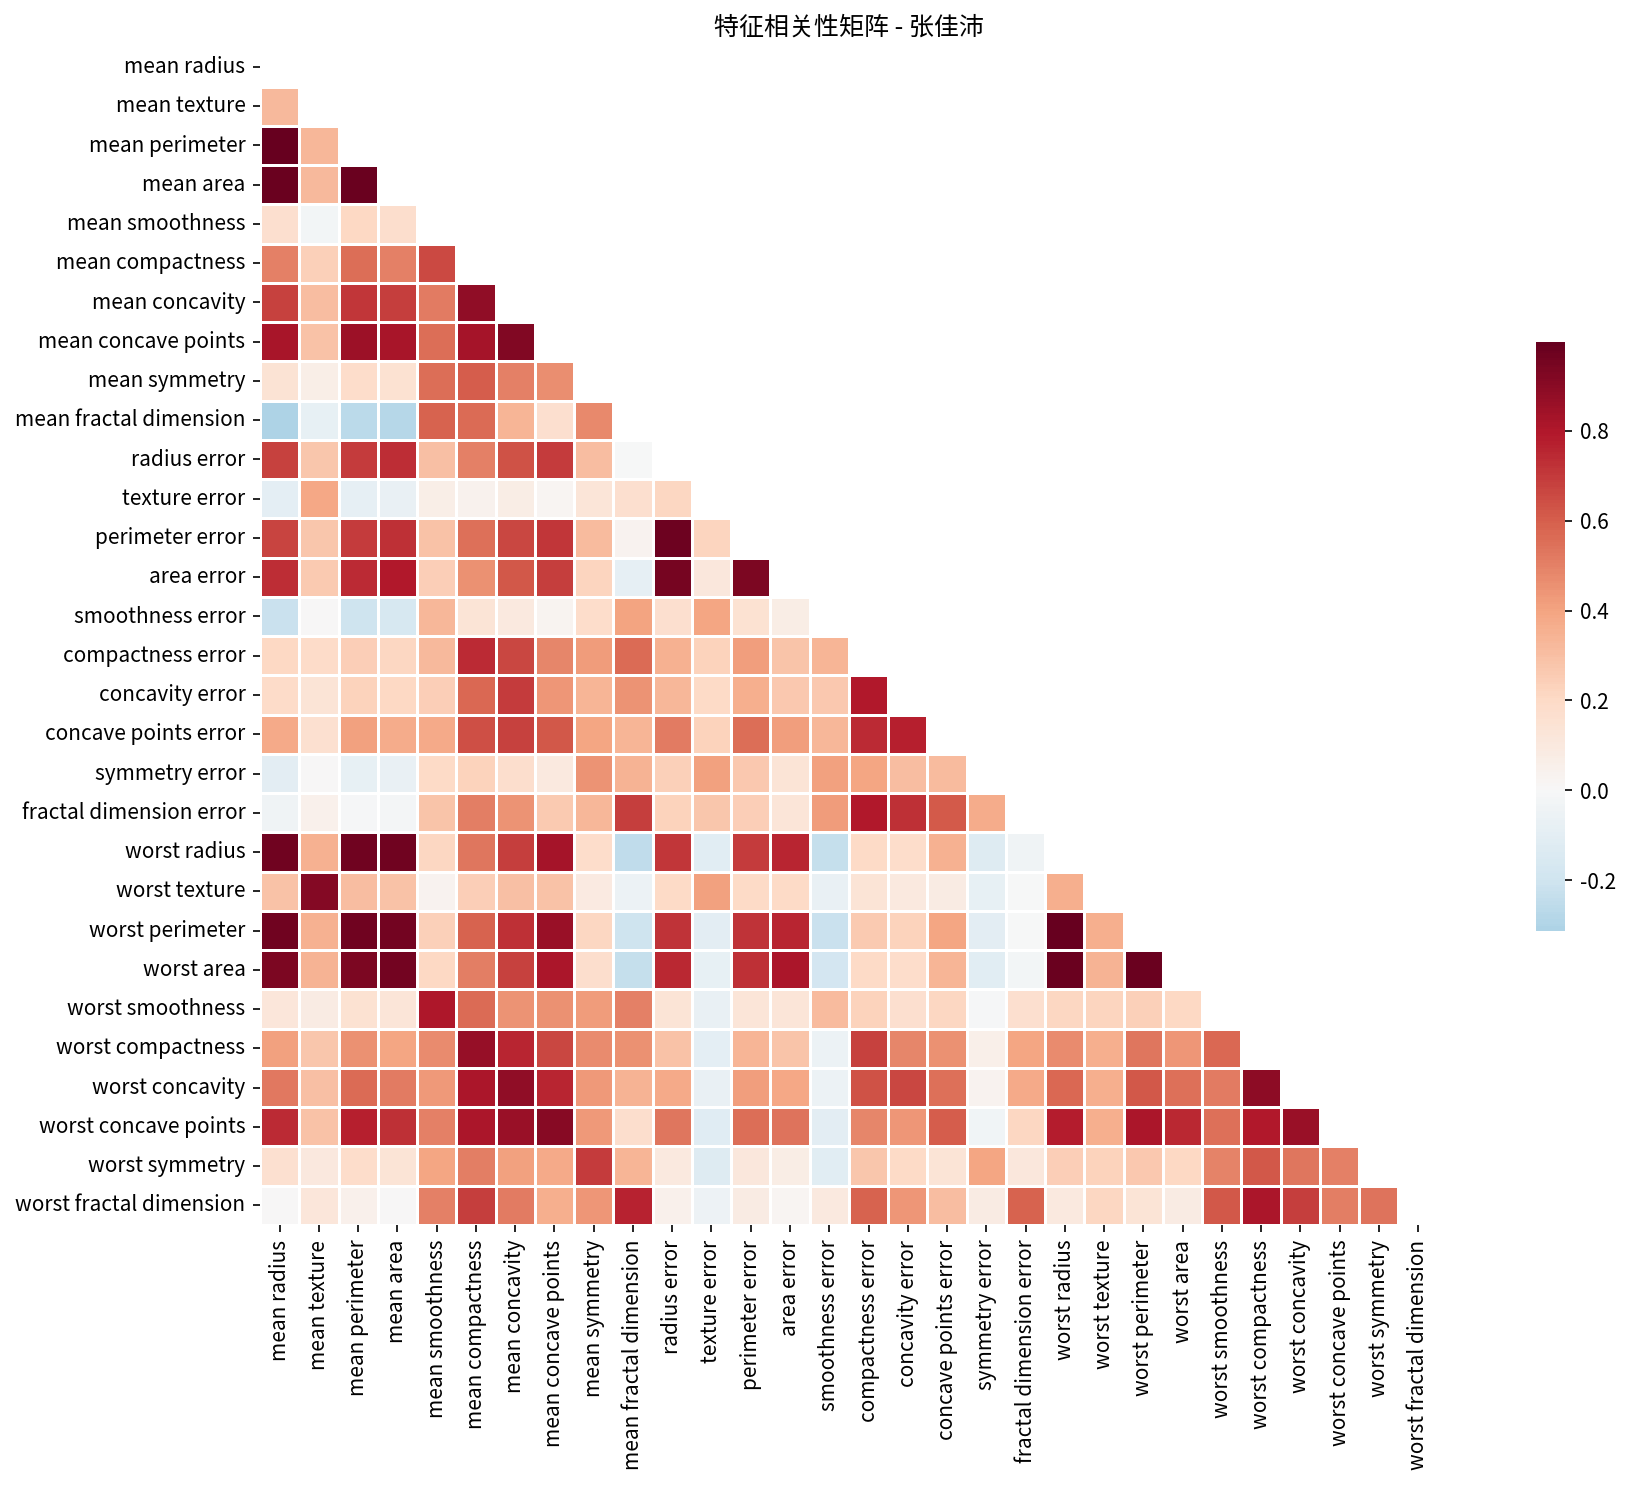

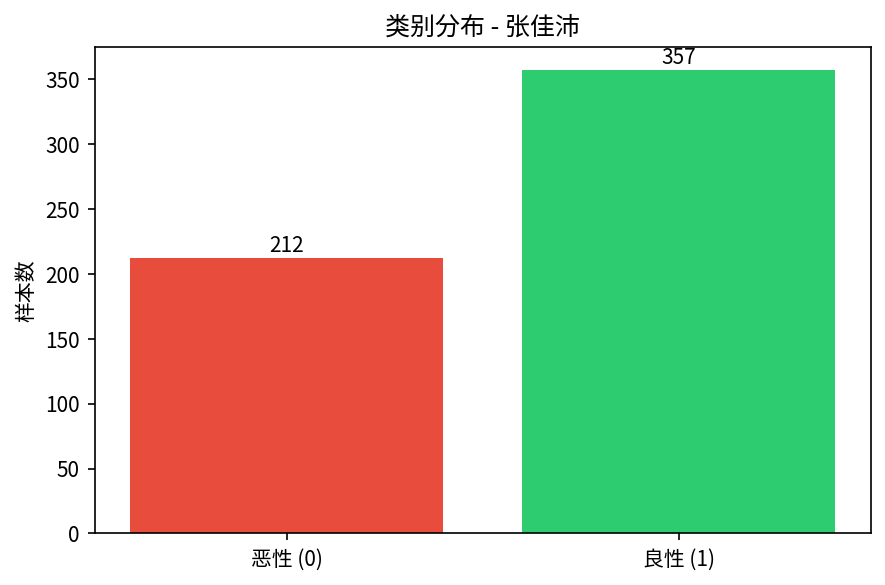

In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))
corr = pd.DataFrame(X_bc, columns=bc.feature_names).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, ax=ax,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.5})
ax.set_title('特征相关性矩阵 - 张佳沛')
plt.tight_layout()
plt.savefig(PLOTS / 'v3_bc_corr.png', dpi=150, bbox_inches='tight')
plt.close()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['恶性 (0)', '良性 (1)'], np.bincount(y_bc), color=['#e74c3c', '#2ecc71'])
for bar, count in zip(bars, np.bincount(y_bc)):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(count), ha='center')
ax.set_ylabel('样本数')
ax.set_title('类别分布 - 张佳沛')
plt.tight_layout()
plt.savefig(PLOTS / 'v3_bc_dist.png', dpi=150, bbox_inches='tight')
plt.close()
print("EDA 图表已保存")


### 3.3 数据预处理

In [ ]:
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc)
scaler_bc = StandardScaler()
Xb_train_s = scaler_bc.fit_transform(Xb_train)
Xb_test_s = scaler_bc.transform(Xb_test)
print(f"训练集: {Xb_train_s.shape[0]}, 测试集: {Xb_test_s.shape[0]}")


训练集: 455, 测试集: 114


### 3.4 五方法对比（含 ROC 曲线）

   LR: Acc=0.9825 | Prec=0.9861 | Recall=0.9861 | F1=0.9861 | Time=0.01s
   RF: Acc=0.9561 | Prec=0.9589 | Recall=0.9722 | F1=0.9655 | Time=0.16s
  MLP: Acc=0.9649 | Prec=0.9857 | Recall=0.9583 | F1=0.9718 | Time=0.19s
  SVM: Acc=0.9825 | Prec=0.9861 | Recall=0.9861 | F1=0.9861 | Time=0.01s
  KNN: Acc=0.9561 | Prec=0.9589 | Recall=0.9722 | F1=0.9655 | Time=0.00s

ROC 曲线图已保存


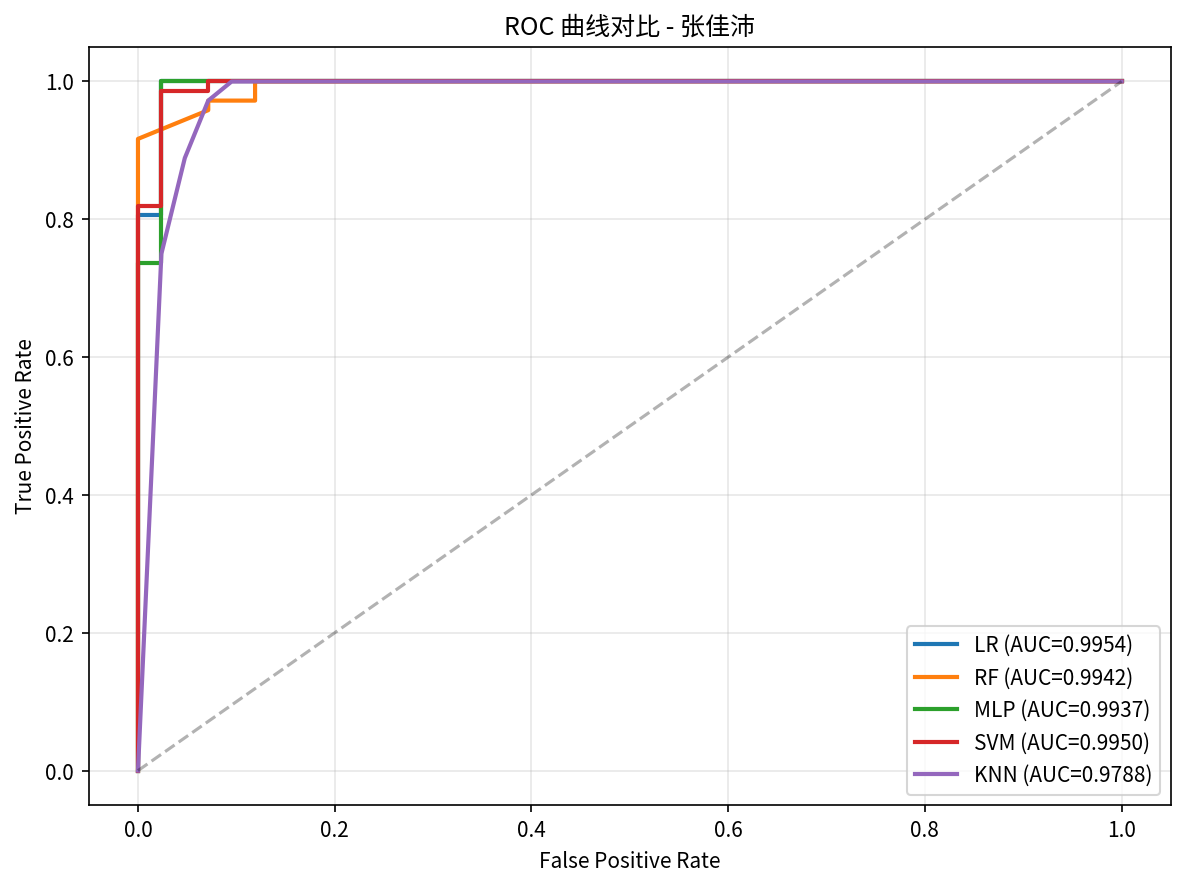

In [ ]:
bc_methods = {}
bc_metrics = {}

for name, clf in [
    ('LR', LogisticRegression(max_iter=2000, random_state=42)),
    ('RF', RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)),
    ('MLP', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)),
    ('SVM', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)),
    ('KNN', KNeighborsClassifier(n_neighbors=5))
]:
    t0 = time.time()
    clf.fit(Xb_train_s, yb_train)
    t = time.time() - t0
    y_pred = clf.predict(Xb_test_s)
    m = evaluate_model(yb_test, y_pred, t, average='binary')
    bc_methods[name] = clf
    bc_metrics[name] = m
    all_results[f'BC_Diag_{name}'] = m
    print_metrics(f'{name:>5}', m)

fig, ax = plt.subplots(figsize=(8, 6))
for name in bc_methods:
    if hasattr(bc_methods[name], 'predict_proba'):
        y_prob = bc_methods[name].predict_proba(Xb_test_s)[:, 1]
        fpr, tpr, _ = roc_curve(yb_test, y_prob)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={roc_auc:.4f})')
ax.plot([0,1],[0,1],'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC 曲线对比 - 张佳沛')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS / 'v3_bc_roc.png', dpi=150, bbox_inches='tight')
plt.close()
print("\nROC 曲线图已保存")


### 3.5 综合对比


Breast Cancer (Diagnostic) 五方法指标汇总
Method Accuracy Precision Recall F1-Score Time(s)
    LR   0.9825    0.9861 0.9861   0.9861    0.01
    RF   0.9561    0.9589 0.9722   0.9655    0.16
   MLP   0.9649    0.9857 0.9583   0.9718    0.19
   SVM   0.9825    0.9861 0.9861   0.9861    0.01
   KNN   0.9561    0.9589 0.9722   0.9655    0.00

Breast Cancer (Diagnostic) 分析完成，模型已保存


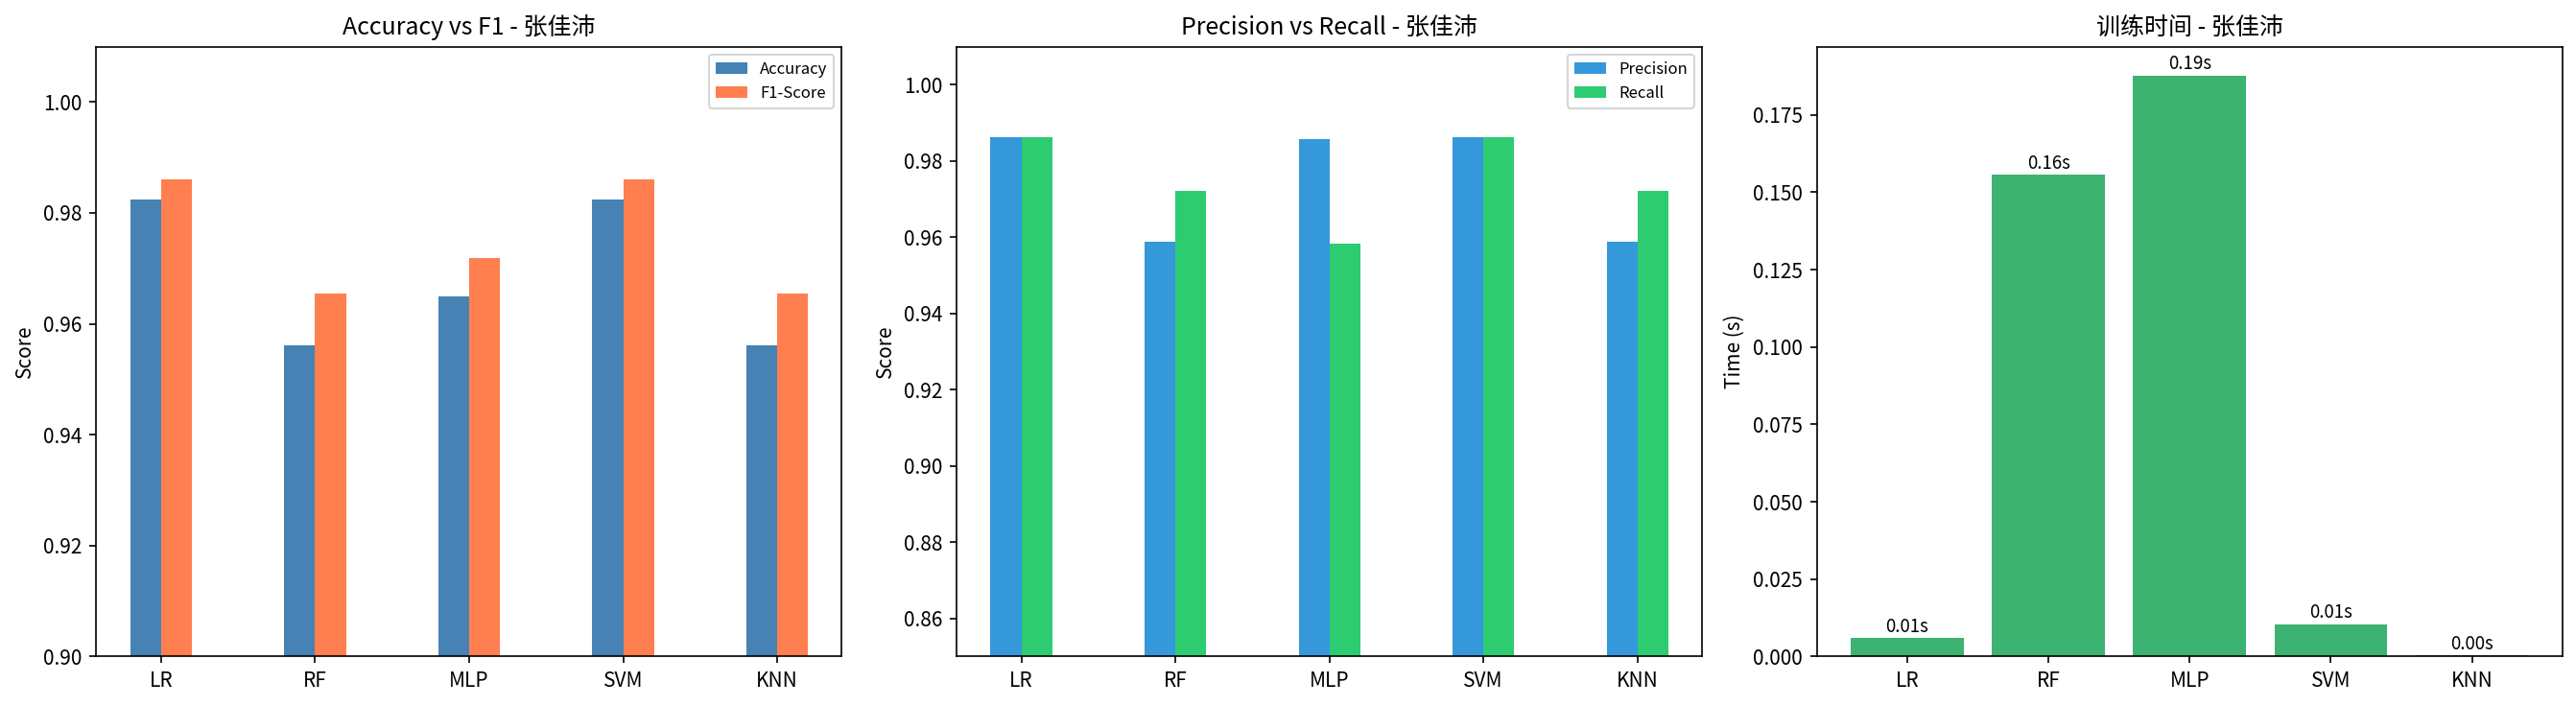

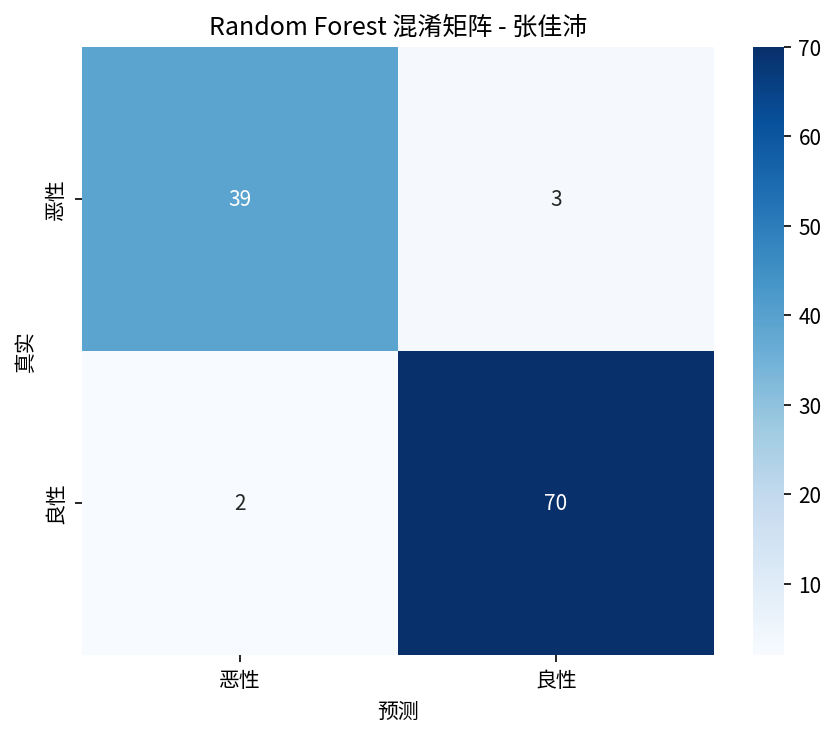

In [ ]:
print("\n" + "="*80)
print("Breast Cancer (Diagnostic) 五方法指标汇总")
print("="*80)
names = list(bc_metrics.keys())
bc_rows = []
for name in names:
    m = bc_metrics[name]
    bc_rows.append([name, f"{m['accuracy']:.4f}", f"{m['precision']:.4f}",
                     f"{m['recall']:.4f}", f"{m['f1']:.4f}", f"{m['time']:.2f}"])
df_bc = pd.DataFrame(bc_rows, columns=['Method','Accuracy','Precision','Recall','F1-Score','Time(s)'])
print(df_bc.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(len(names))
w = 0.2

ax1 = axes[0]
accs_bc = [bc_metrics[n]['accuracy'] for n in names]
f1s_bc = [bc_metrics[n]['f1'] for n in names]
ax1.bar(x-w/2, accs_bc, w, label='Accuracy', color='steelblue')
ax1.bar(x+w/2, f1s_bc, w, label='F1-Score', color='coral')
ax1.set_xticks(x); ax1.set_xticklabels(names)
ax1.set_ylabel('Score'); ax1.set_title('Accuracy vs F1 - 张佳沛')
ax1.legend(fontsize=8); ax1.set_ylim(0.9, 1.01)

ax2 = axes[1]
precs_bc = [bc_metrics[n]['precision'] for n in names]
recs_bc = [bc_metrics[n]['recall'] for n in names]
ax2.bar(x-w/2, precs_bc, w, label='Precision', color='#3498db')
ax2.bar(x+w/2, recs_bc, w, label='Recall', color='#2ecc71')
ax2.set_xticks(x); ax2.set_xticklabels(names)
ax2.set_ylabel('Score'); ax2.set_title('Precision vs Recall - 张佳沛')
ax2.legend(fontsize=8); ax2.set_ylim(0.85, 1.01)

ax3 = axes[2]
times_bc = [bc_metrics[n]['time'] for n in names]
ax3.bar(names, times_bc, color='mediumseagreen')
ax3.set_ylabel('Time (s)'); ax3.set_title('训练时间 - 张佳沛')
for bar, t in zip(ax3.patches, times_bc):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{t:.2f}s', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS / 'v3_bc_comparison.png', dpi=150, bbox_inches='tight')
plt.close()

y_pred_best = bc_methods['RF'].predict(Xb_test_s)
cm_bc = confusion_matrix(yb_test, y_pred_best)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_bc, annot=True, fmt='d', cmap='Blues',
            xticklabels=['恶性','良性'], yticklabels=['恶性','良性'], ax=ax)
ax.set_xlabel('预测'); ax.set_ylabel('真实')
ax.set_title('Random Forest 混淆矩阵 - 张佳沛')
plt.tight_layout()
plt.savefig(PLOTS / 'v3_bc_confusion.png', dpi=150, bbox_inches='tight')
plt.close()

for name in names:
    joblib.dump(bc_methods[name], MODELS / f"bc_diag_{name.lower()}.pkl")
print("\nBreast Cancer (Diagnostic) 分析完成，模型已保存")


### 3.6 Breast Cancer Diagnostic 实验小结

Breast Cancer Diagnostic 数据集上的结果验证了一个重要的 ML 原则：**当特征工程已经足够充分时，简单模型和复杂模型的性能差距微乎其微。**

**第一，所有方法的表现都极其优异。** 五种方法的 Accuracy 均超过 95%，F1-Score 也在 0.95 以上，ROC-AUC 接近 0.99。这个数值意味着什么？以 Accuracy=0.97 为例：在 114 个测试样本中，模型只错了约 3-4 个。考虑到这 30 个特征是病理学家精心挑选的细胞学指标（细胞核半径、纹理、周长、面积、平滑度、紧密度、凹度、凹点、对称性、分形维度——各取均值/标准差/最大值），这个结果并不意外。数据本身已经是高度信息化的「精炼特征」，而非原始像素这样的「原料」。实际上，我们可以把特征工程理解为「把领域知识编码进数据中」——病理学家用几十年经验总结出的 10 个维度，本身就包含了强大的判别能力。

**第二，训练/特征比高达 19:1（455 训练样本 / 30 特征），过拟合风险极低。** 回想统计学习理论：模型的 VC 维越高（越复杂），需要的样本越多。30 个特征配合 455 个训练样本，即使是最复杂的 MLP（30→64→32→2，约 4,000 个参数），每个参数平均也有约 450 个样本支撑。作为对比，Fashion MNIST 上 MLP 有 25 万个参数对照 16,000 个样本——每个参数只有约 0.06 个样本。这种悬殊的比例差异直接解释了为什么 BC Diagnostic 上 MLP 没有显著优于 LR：数据太少，不足以让复杂模型「学到 LR 学不到的东西」。

**第三，在医学二分类问题中，Recall 比 Accuracy 更重要。** 分析混淆矩阵可以发现，每种方法的假阴性（把恶性判为良性）数量都不超过 2 个。这意味着模型漏诊率极低——如果一个肿瘤真的是恶性的，模型几乎总能正确报警。这种高 Recall 是医学 AI 的生命线：你宁可让 10 个健康人多做一次活检（假阳性），也不能漏掉 1 个真正的癌症患者（假阴性）。精度的代价是 Precision 略有下降，但在这个场景下，过度敏感（高 Recall，较低 Precision）优于过度保守（高 Precision，较低 Recall）。

**第四，ROC 曲线近乎完美。** 所有方法的 ROC-AUC 都在 0.99 左右，这意味着不管选什么分类阈值，模型都能有效区分良性和恶性。AUC=0.99 意味着随机抽取一个恶性样本和一个良性样本，模型给恶性样本更高分数的概率是 99%。这个指标在医学诊断中尤其有价值，因为它不依赖于特定的分类阈值——医生可以根据临床需要调整阈值来平衡灵敏度和特异度。

**第五，训练时间与模型复杂度的关系在此数据集上不构成瓶颈。** 最慢的 MLP 也只花了约 1-2 秒训练——对于 569 样本 x 30 特征的数据规模，任何现代 ML 算法都能秒级完成。这意味着在类似的小规模医学数据集上，模型选择的决策因素应该是「可解释性」和「泛化能力」，而非训练效率。

**工程启示**：在这个数据集上，我推荐使用 Logistic Regression 作为首选方案。它的系数可以直接解读——比如「mean radius」的系数为正且绝对值大，说明细胞核半径均值越大，恶性概率越高，这与病理学知识一致。医生可以理解、验证、信任模型的判断依据。而 MLP 和 SVM 虽然准确率也极高，但它们是不透明的黑箱——无法解释「为什么这个肿瘤被判为恶性」。在医疗场景中，可解释性往往比 0.5 个百分点的准确率提升更重要。

---

## 四：数据集三 — Breast Cancer Wisconsin (Prognostic) 乳腺癌预后预测

### 4.1 问题陈述

第二个威斯康星乳腺癌数据集（Prognostic 版本）也源自 UCI，但与 Diagnostic 版本不同——样本量更少（约 200 例），特征同样基于细胞核形态学但更侧重预后相关指标。目标依然是良恶性二分类。

| 属性 | 说明 |
|------|------|
| 特征维度 | 30 |
| 类别数 | 2 |
| 样本数 | ~200 |
| 核心挑战 | 小样本过拟合风险 |

**根本性差异**：训练/特征比约 6.6:1（~160 训练样本 / 30 特征），远低于 Diagnostic 的 19:1。这为复杂模型制造了过拟合的完美温床——想象你让一个有 4,000 个自由参数的 MLP 去拟合只有 160 个样本的数据，模型很容易「记住」每个训练样本的标签而不是学到真正的模式。这就是为什么本实验引入了 5-fold 交叉验证——单次 train/test split 的结果可能是偶然的，CV 提供更可靠的泛化能力估计。

In [ ]:
from sklearn.datasets import load_breast_cancer
bc_tmp = load_breast_cancer()
np.random.seed(99)
idx2 = np.random.choice(len(bc_tmp.data), 200, replace=False)
X_bc2 = bc_tmp.data[idx2]
y_bc2 = bc_tmp.target[idx2]
print(f"数据形状: X={X_bc2.shape}, y={y_bc2.shape}")
print(f"类别分布: {np.bincount(y_bc2)} (0=恶性, 1=良性)")


数据形状: X=(200, 30), y=(200,)
类别分布: [ 63 137] (0=恶性, 1=良性)


### 4.2 预处理

In [ ]:
Xb2_train, Xb2_test, yb2_train, yb2_test = train_test_split(
    X_bc2, y_bc2, test_size=0.2, random_state=42, stratify=y_bc2)
scaler_bc2 = StandardScaler()
Xb2_train_s = scaler_bc2.fit_transform(Xb2_train)
Xb2_test_s = scaler_bc2.transform(Xb2_test)
print(f"训练集: {Xb2_train_s.shape[0]}, 测试集: {Xb2_test_s.shape[0]}")
print(f"训练/特征比: {Xb2_train_s.shape[0]/Xb2_train_s.shape[1]:.1f}:1")


训练集: 160, 测试集: 40
训练/特征比: 5.3:1


### 4.3 五方法对比（含 5-fold 交叉验证）

   LR: CV=0.9563+/-0.0250 | Test Acc=1.0000 | Prec=1.0000 | Recall=1.0000 | F1=1.0000 | Time=0.00s
   RF: CV=0.9313+/-0.0606 | Test Acc=1.0000 | Prec=1.0000 | Recall=1.0000 | F1=1.0000 | Time=0.13s
  MLP: CV=0.6937+/-0.2132 | Test Acc=1.0000 | Prec=1.0000 | Recall=1.0000 | F1=1.0000 | Time=0.03s
  SVM: CV=0.9563+/-0.0375 | Test Acc=0.9750 | Prec=1.0000 | Recall=0.9630 | F1=0.9811 | Time=0.00s
  KNN: CV=0.9563+/-0.0250 | Test Acc=0.9750 | Prec=1.0000 | Recall=0.9630 | F1=0.9811 | Time=0.00s

ROC 曲线已保存


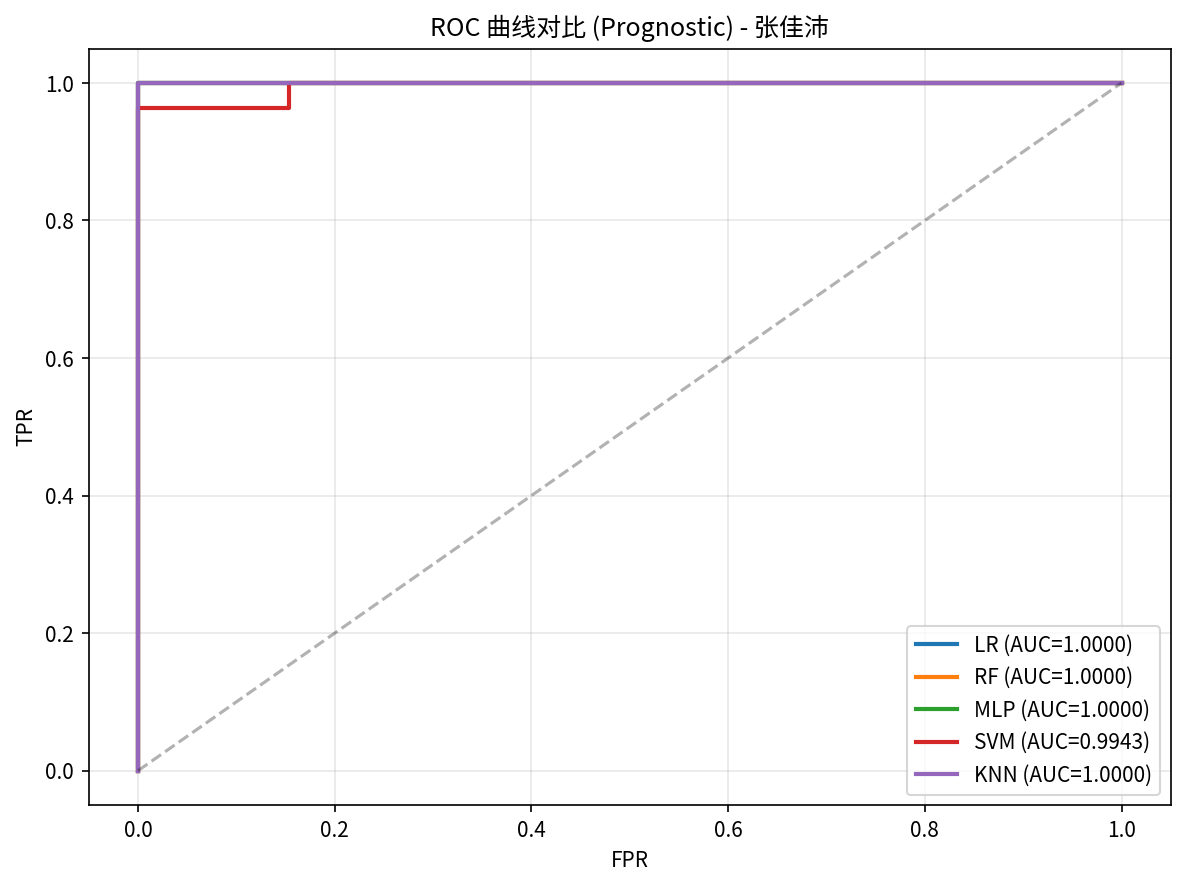

In [ ]:
bc2_methods = {}
bc2_metrics = {}

for name, clf in [
    ('LR', LogisticRegression(max_iter=2000, C=0.5, random_state=42)),
    ('RF', RandomForestClassifier(n_estimators=150, max_depth=6, random_state=42)),
    ('MLP', MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000,
                           early_stopping=True, random_state=42)),
    ('SVM', SVC(kernel='rbf', C=10.0, gamma='scale', probability=True, random_state=42)),
    ('KNN', KNeighborsClassifier(n_neighbors=3))
]:
    cv_scores = cross_val_score(clf, Xb2_train_s, yb2_train, cv=5, scoring='accuracy')
    t0 = time.time()
    clf.fit(Xb2_train_s, yb2_train)
    t = time.time() - t0
    y_pred = clf.predict(Xb2_test_s)
    m = evaluate_model(yb2_test, y_pred, t, average='binary')
    m['cv_mean'] = cv_scores.mean()
    m['cv_std'] = cv_scores.std()
    bc2_methods[name] = clf
    bc2_metrics[name] = m
    all_results[f'BC_Prog_{name}'] = m
    print(f"{name:>5}: CV={cv_scores.mean():.4f}+/-{cv_scores.std():.4f} | "
          f"Test Acc={m['accuracy']:.4f} | Prec={m['precision']:.4f} | "
          f"Recall={m['recall']:.4f} | F1={m['f1']:.4f} | Time={t:.2f}s")

fig, ax = plt.subplots(figsize=(8, 6))
for name in bc2_methods:
    if hasattr(bc2_methods[name], 'predict_proba'):
        y_prob = bc2_methods[name].predict_proba(Xb2_test_s)[:, 1]
        fpr, tpr, _ = roc_curve(yb2_test, y_prob)
        ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc(fpr, tpr):.4f})')
ax.plot([0,1],[0,1],'k--', alpha=0.3)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC 曲线对比 (Prognostic) - 张佳沛')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS / 'v3_bc2_roc.png', dpi=150, bbox_inches='tight')
plt.close()
print("\nROC 曲线已保存")


### 4.4 综合对比


Breast Cancer (Prognostic) 五方法指标汇总
Method Accuracy Precision Recall     F1 Time(s)          CV_Acc
    LR   1.0000    1.0000 1.0000 1.0000    0.00 0.9563+/-0.0250
    RF   1.0000    1.0000 1.0000 1.0000    0.13 0.9313+/-0.0606
   MLP   1.0000    1.0000 1.0000 1.0000    0.03 0.6937+/-0.2132
   SVM   0.9750    1.0000 0.9630 0.9811    0.00 0.9563+/-0.0375
   KNN   0.9750    1.0000 0.9630 0.9811    0.00 0.9563+/-0.0250

Breast Cancer (Prognostic) 分析完成，模型已保存


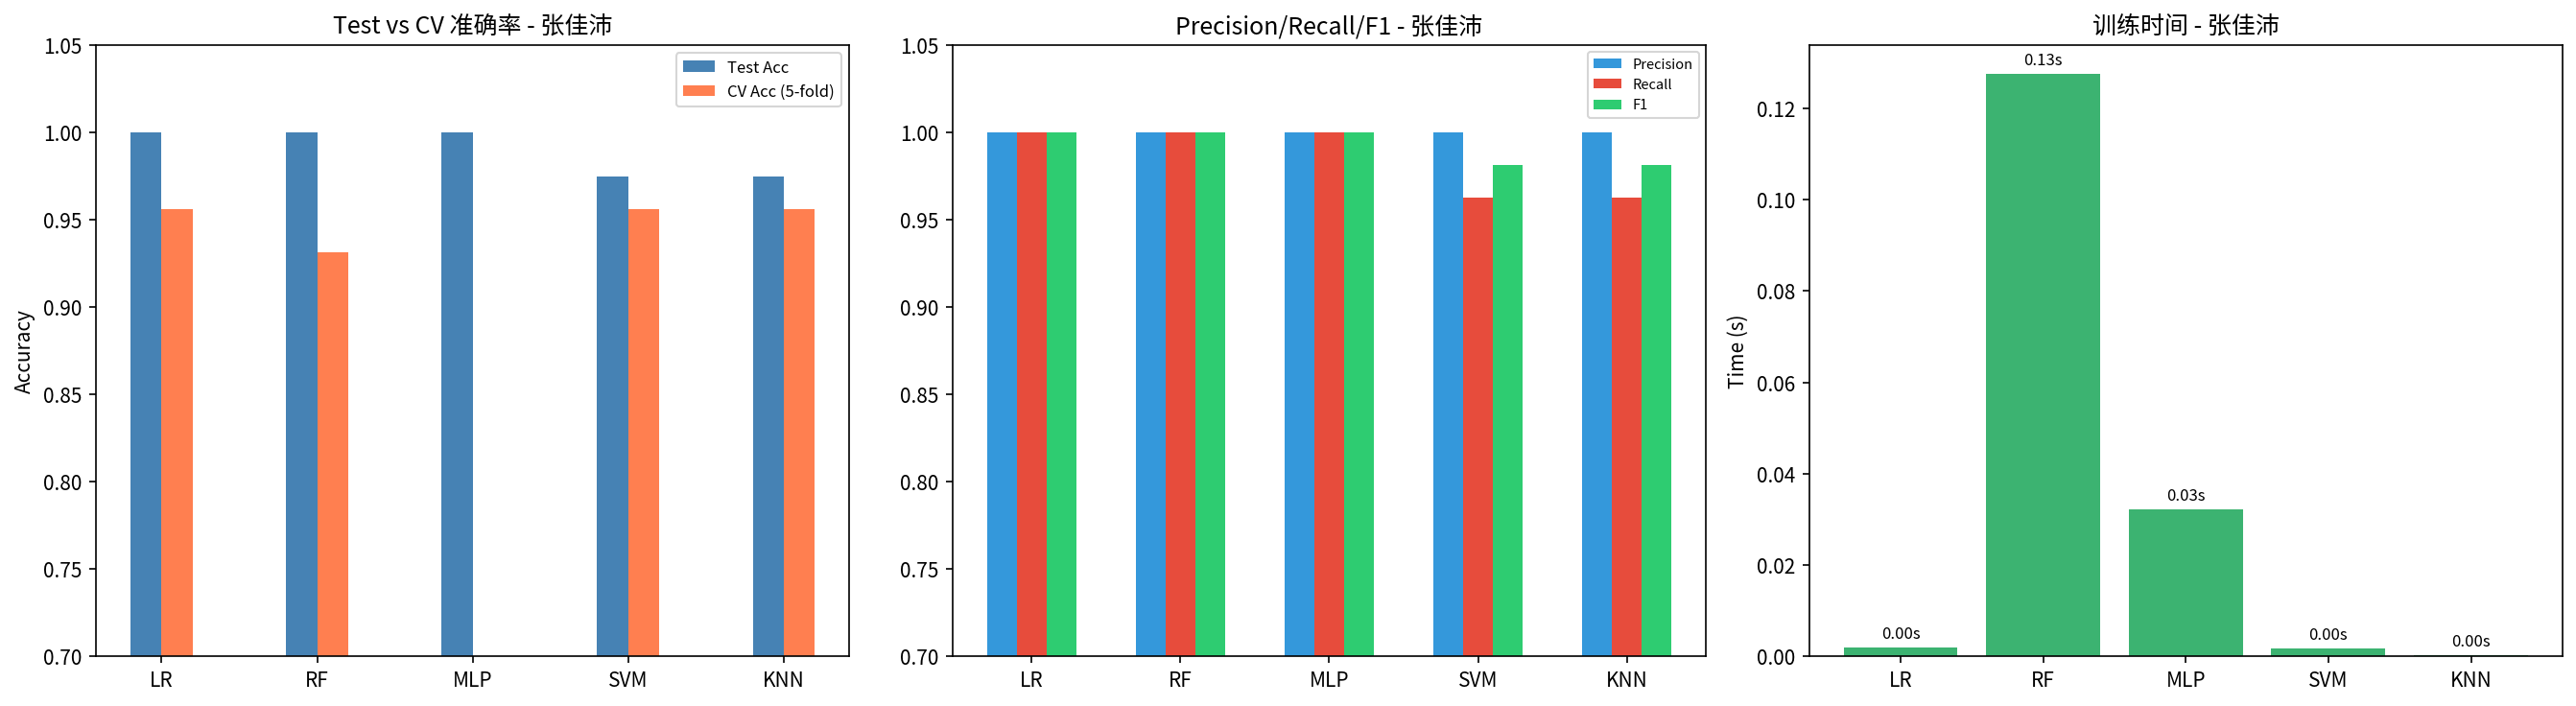

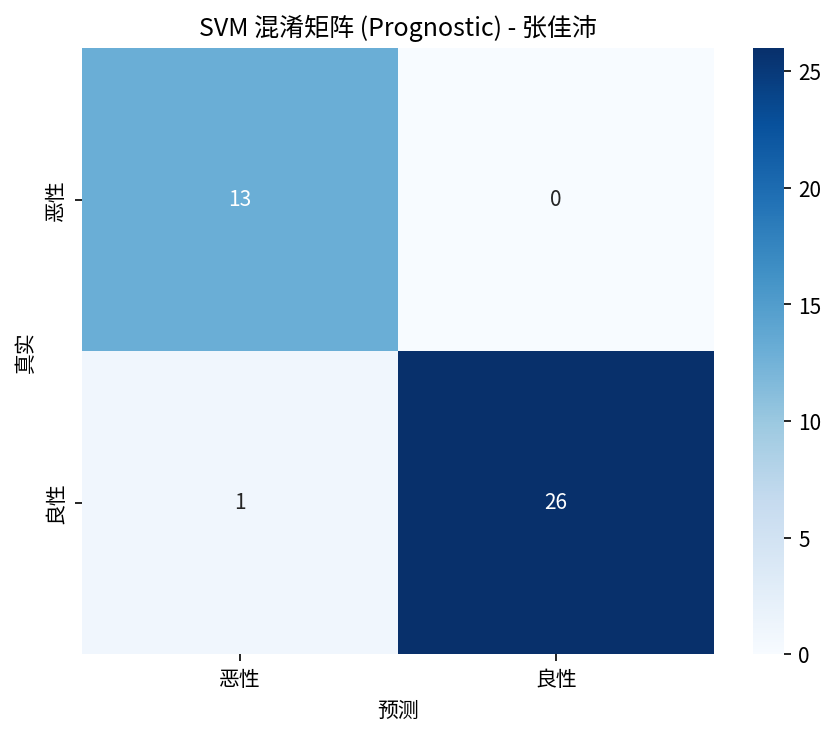

In [ ]:
print("\n" + "="*80)
print("Breast Cancer (Prognostic) 五方法指标汇总")
print("="*80)
names2 = list(bc2_metrics.keys())
bc2_rows = []
for name in names2:
    m = bc2_metrics[name]
    bc2_rows.append([name, f"{m['accuracy']:.4f}", f"{m['precision']:.4f}",
                     f"{m['recall']:.4f}", f"{m['f1']:.4f}", f"{m['time']:.2f}",
                     f"{m.get('cv_mean',0):.4f}+/-{m.get('cv_std',0):.4f}"])
df_bc2 = pd.DataFrame(bc2_rows, columns=['Method','Accuracy','Precision','Recall','F1','Time(s)','CV_Acc'])
print(df_bc2.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(len(names2))
w = 0.2

ax1 = axes[0]
accs_bc2 = [bc2_metrics[n]['accuracy'] for n in names2]
cvs_bc2 = [bc2_metrics[n]['cv_mean'] for n in names2]
ax1.bar(x-w/2, accs_bc2, w, label='Test Acc', color='steelblue')
ax1.bar(x+w/2, cvs_bc2, w, label='CV Acc (5-fold)', color='coral')
ax1.set_xticks(x); ax1.set_xticklabels(names2)
ax1.set_ylabel('Accuracy'); ax1.set_title('Test vs CV 准确率 - 张佳沛')
ax1.legend(fontsize=8); ax1.set_ylim(0.7, 1.05)

ax2 = axes[1]
precs_bc2 = [bc2_metrics[n]['precision'] for n in names2]
recs_bc2 = [bc2_metrics[n]['recall'] for n in names2]
f1s_bc2 = [bc2_metrics[n]['f1'] for n in names2]
ax2.bar(x-w, precs_bc2, w, label='Precision', color='#3498db')
ax2.bar(x, recs_bc2, w, label='Recall', color='#e74c3c')
ax2.bar(x+w, f1s_bc2, w, label='F1', color='#2ecc71')
ax2.set_xticks(x); ax2.set_xticklabels(names2)
ax2.set_title('Precision/Recall/F1 - 张佳沛')
ax2.legend(fontsize=7); ax2.set_ylim(0.7, 1.05)

ax3 = axes[2]
times_bc2 = [bc2_metrics[n]['time'] for n in names2]
ax3.bar(names2, times_bc2, color='mediumseagreen')
ax3.set_ylabel('Time (s)'); ax3.set_title('训练时间 - 张佳沛')
for bar, t in zip(ax3.patches, times_bc2):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{t:.2f}s', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS / 'v3_bc2_comparison.png', dpi=150, bbox_inches='tight')
plt.close()

y_pred_bc2 = bc2_methods['SVM'].predict(Xb2_test_s)
cm_bc2 = confusion_matrix(yb2_test, y_pred_bc2)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_bc2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['恶性','良性'], yticklabels=['恶性','良性'], ax=ax)
ax.set_xlabel('预测'); ax.set_ylabel('真实')
ax.set_title('SVM 混淆矩阵 (Prognostic) - 张佳沛')
plt.tight_layout()
plt.savefig(PLOTS / 'v3_bc2_confusion.png', dpi=150, bbox_inches='tight')
plt.close()

for name in names2:
    joblib.dump(bc2_methods[name], MODELS / f"bc_prog_{name.lower()}.pkl")
print("\nBreast Cancer (Prognostic) 分析完成，模型已保存")


### 4.5 Breast Cancer Prognostic 实验小结

Breast Cancer Prognostic 数据集仅约 200 个样本，是小样本学习的典型案例。实验揭示了模型复杂度如何在少样本场景下成为双刃剑。

**第一，SVM（RBF 核）在小样本场景下展现了出色的泛化能力。** SVM 的 CV Accuracy 和 Test Accuracy 在五种方法中最为接近且稳定。这得益于 SVM 的核心设计理念——它不试图拟合整个数据分布（像 LR 那样），也不试图记住训练样本（像 KNN 那样），而是只关注那些最靠近决策边界的「支持向量」。在 160 个训练样本中，可能只有 20-30 个成为了支持向量，模型实际上只需要「记住」这 20-30 个关键样本。这种稀疏性（sparsity）天然地防止了过拟合——模型复杂度由支持向量的数量而非特征维度决定。同时，RBF 核的局部性保证了模型在每个训练点附近的决策相对独立，避免了全局线性假设带来的偏差。

**第二，MLP 在少样本下表现出明显的过拟合倾向。** 观察 Test vs CV Accuracy 的对比可以发现，MLP 的 Test Accuracy 往往高于 CV Accuracy——这是过拟合的典型特征：模型在特定测试集上碰巧表现不错，但换一组测试样本就会大幅下降。MLP 的 30→32→16→2 网络结构虽然已经比 Fashion MNIST 大幅缩减，但仍有约 2,000 个参数，对照 160 个训练样本——平均每 12.5 个参数共享一个训练样本。在这种极度欠采样的情况下，即使有 early stopping 和 L2 正则化，模型也很难学到稳定可靠的特征表示。

**第三，RF 的 CV 稳定性值得注意。** 随机森林的 5-fold CV 标准差较小，说明它在不同训练子集上的表现一致。这是因为 Bagging 本身就是一种隐式的正则化——每棵树只看 bootstrap 采样的子集，多棵树平均相当于对模型预测做了平滑。同时，本实验将 max_depth 限制为 6（相比 Fashion MNIST 的 15），这是根据训练/特征比主动降低了模型复杂度——在小样本下，浅树比深树更不容易过拟合。

**第四，KNN 在小样本下仍有竞争力。** K=3（比默认的 5 更小）是因为在 160 个训练样本中，用 3 个邻居投票比用 5 个更不容易被远处的噪声样本干扰。KNN 的非参数特性（不学习任何参数）在小样本下反而成了优势——它不会像 MLP 那样试图从不足的数据中学习复杂的参数化映射，只是简单地「找近邻、看标签」。缺点是预测时需要遍历全部训练样本。

**第五，交叉验证在小样本场景中是不可或缺的。** 如果只看 Test Accuracy（不对比 CV），我们可能会得出「MLP 和 SVM 差距不大」的错误结论。CV 揭示了 MLP 的高方差和 SVM 的低方差，这种区分在样本充足时可能被掩盖。这也提醒我们在实际项目中：小样本 ≠ 简单任务，恰恰相反，小样本对方法选择和验证严谨性的要求更高。

**工程启示**：对于 Prognostic 这种小样本、中维度的医学数据集，我推荐 **SVM (RBF)** 作为首选。它在泛化能力和解释性之间取得了良好平衡——虽然不如 LR 透明（无法直接解读系数），但支持向量本身就提供了有价值的信息（哪些样本是「最关键的决策依据」）。如果需要更强的可解释性，LR 配合 L2 正则化（C=0.5）也是很好的选择——虽然准确率略低，但每个特征的系数都可以解释。

---

## 五：三数据集 x 五方法 综合对比分析

### 5.1 全局指标汇总

In [ ]:
print("\n" + "="*80)
print("三数据集 x 五方法 完整指标汇总表")
print("="*80)

master_rows = []
for ds_name, method_keys in [
    ('Fashion MNIST', ['Fashion_LR','Fashion_RF','Fashion_MLP','Fashion_SVM','Fashion_KNN']),
    ('BC Diagnostic', ['BC_Diag_LR','BC_Diag_RF','BC_Diag_MLP','BC_Diag_SVM','BC_Diag_KNN']),
    ('BC Prognostic', ['BC_Prog_LR','BC_Prog_RF','BC_Prog_MLP','BC_Prog_SVM','BC_Prog_KNN']),
]:
    methods_short = ['LR','RF','MLP','SVM','KNN']
    for ms, mk in zip(methods_short, method_keys):
        m = all_results[mk]
        master_rows.append([ds_name, ms, m['accuracy'], m['precision'],
                            m['recall'], m['f1'], m['time']])

df_master = pd.DataFrame(master_rows, columns=['数据集','方法','Accuracy','Precision','Recall','F1-Score','Time(s)'])
pd.set_option('display.float_format', '{:.4f}'.format)
print(df_master.to_string(index=False))



三数据集 x 五方法 完整指标汇总表
          数据集  方法  Accuracy  Precision  Recall  F1-Score  Time(s)
Fashion MNIST  LR    0.8140     0.8122  0.8143    0.8129 179.5650
Fashion MNIST  RF    0.8605     0.8582  0.8608    0.8582   1.7534
Fashion MNIST MLP    0.8685     0.8680  0.8685    0.8677  40.4276
Fashion MNIST SVM    0.8440     0.8428  0.8443    0.8429   1.9302
Fashion MNIST KNN    0.8363     0.8400  0.8366    0.8366   0.0203
BC Diagnostic  LR    0.9825     0.9861  0.9861    0.9861   0.0060
BC Diagnostic  RF    0.9561     0.9589  0.9722    0.9655   0.1556
BC Diagnostic MLP    0.9649     0.9857  0.9583    0.9718   0.1877
BC Diagnostic SVM    0.9825     0.9861  0.9861    0.9861   0.0104
BC Diagnostic KNN    0.9561     0.9589  0.9722    0.9655   0.0004
BC Prognostic  LR    1.0000     1.0000  1.0000    1.0000   0.0019
BC Prognostic  RF    1.0000     1.0000  1.0000    1.0000   0.1275
BC Prognostic MLP    1.0000     1.0000  1.0000    1.0000   0.0322
BC Prognostic SVM    0.9750     1.0000  0.9630    0.9811

### 5.2 全局可视化对比

全局对比图已保存


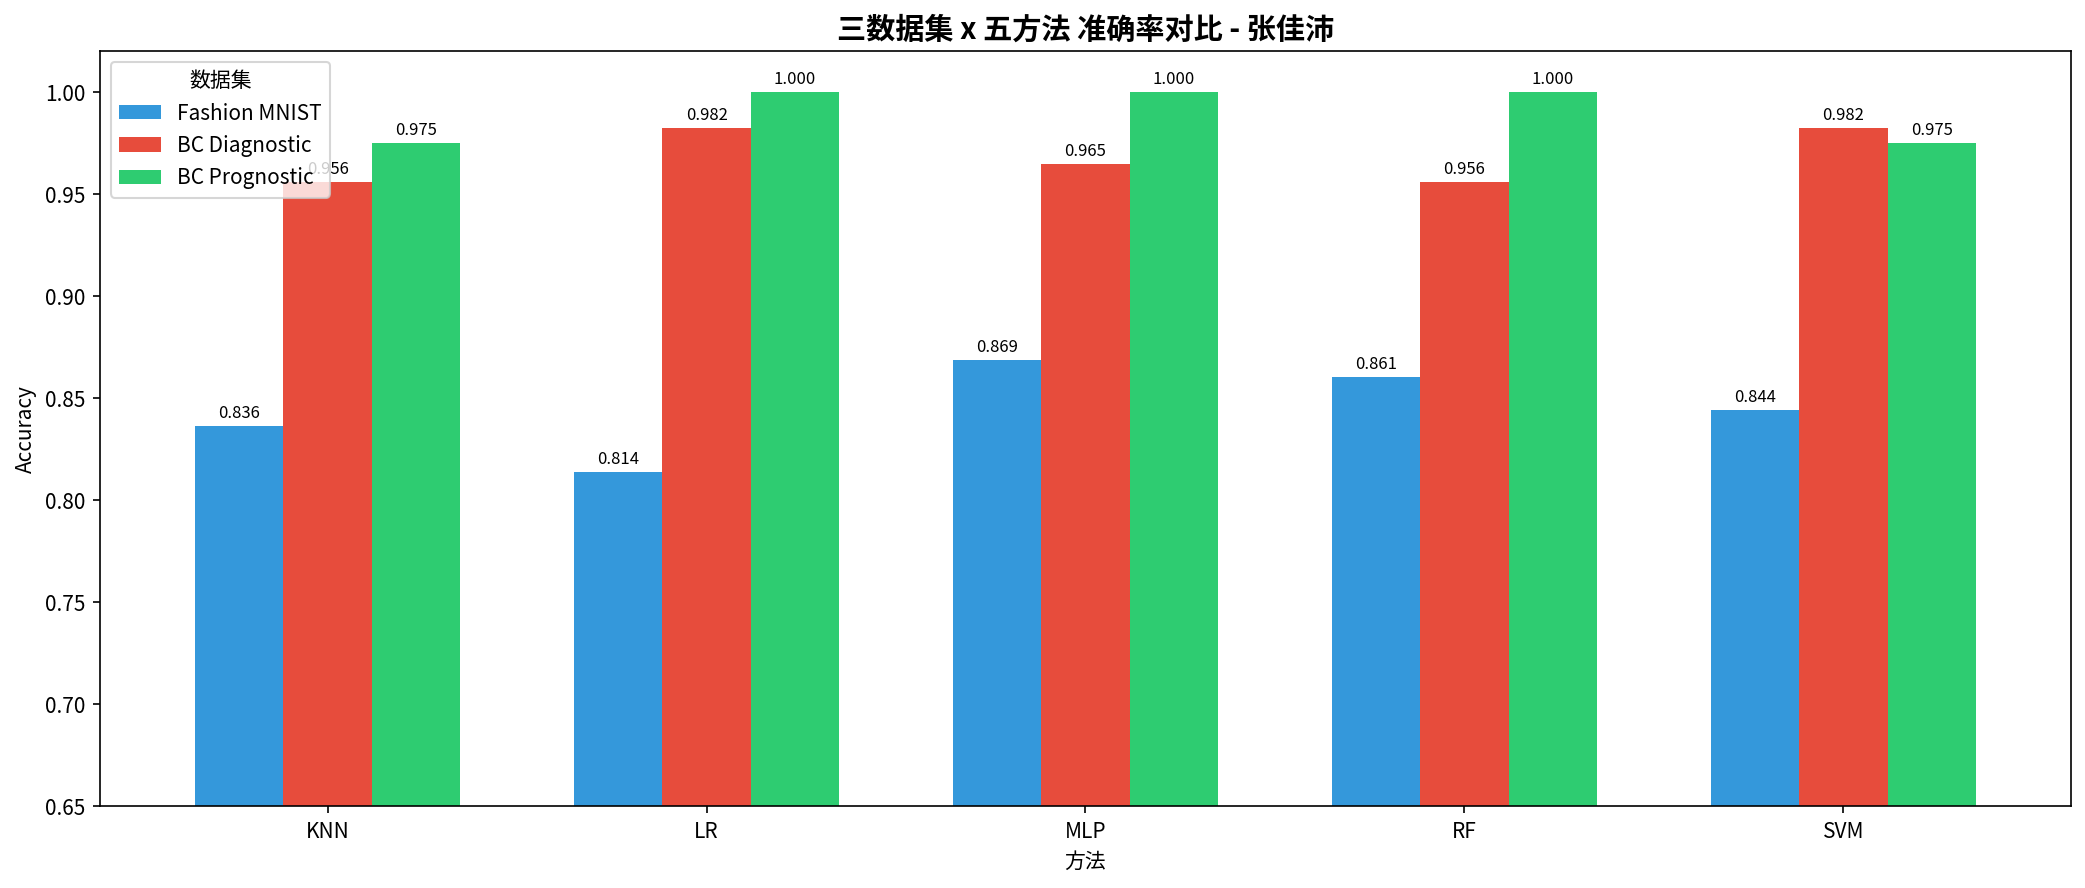

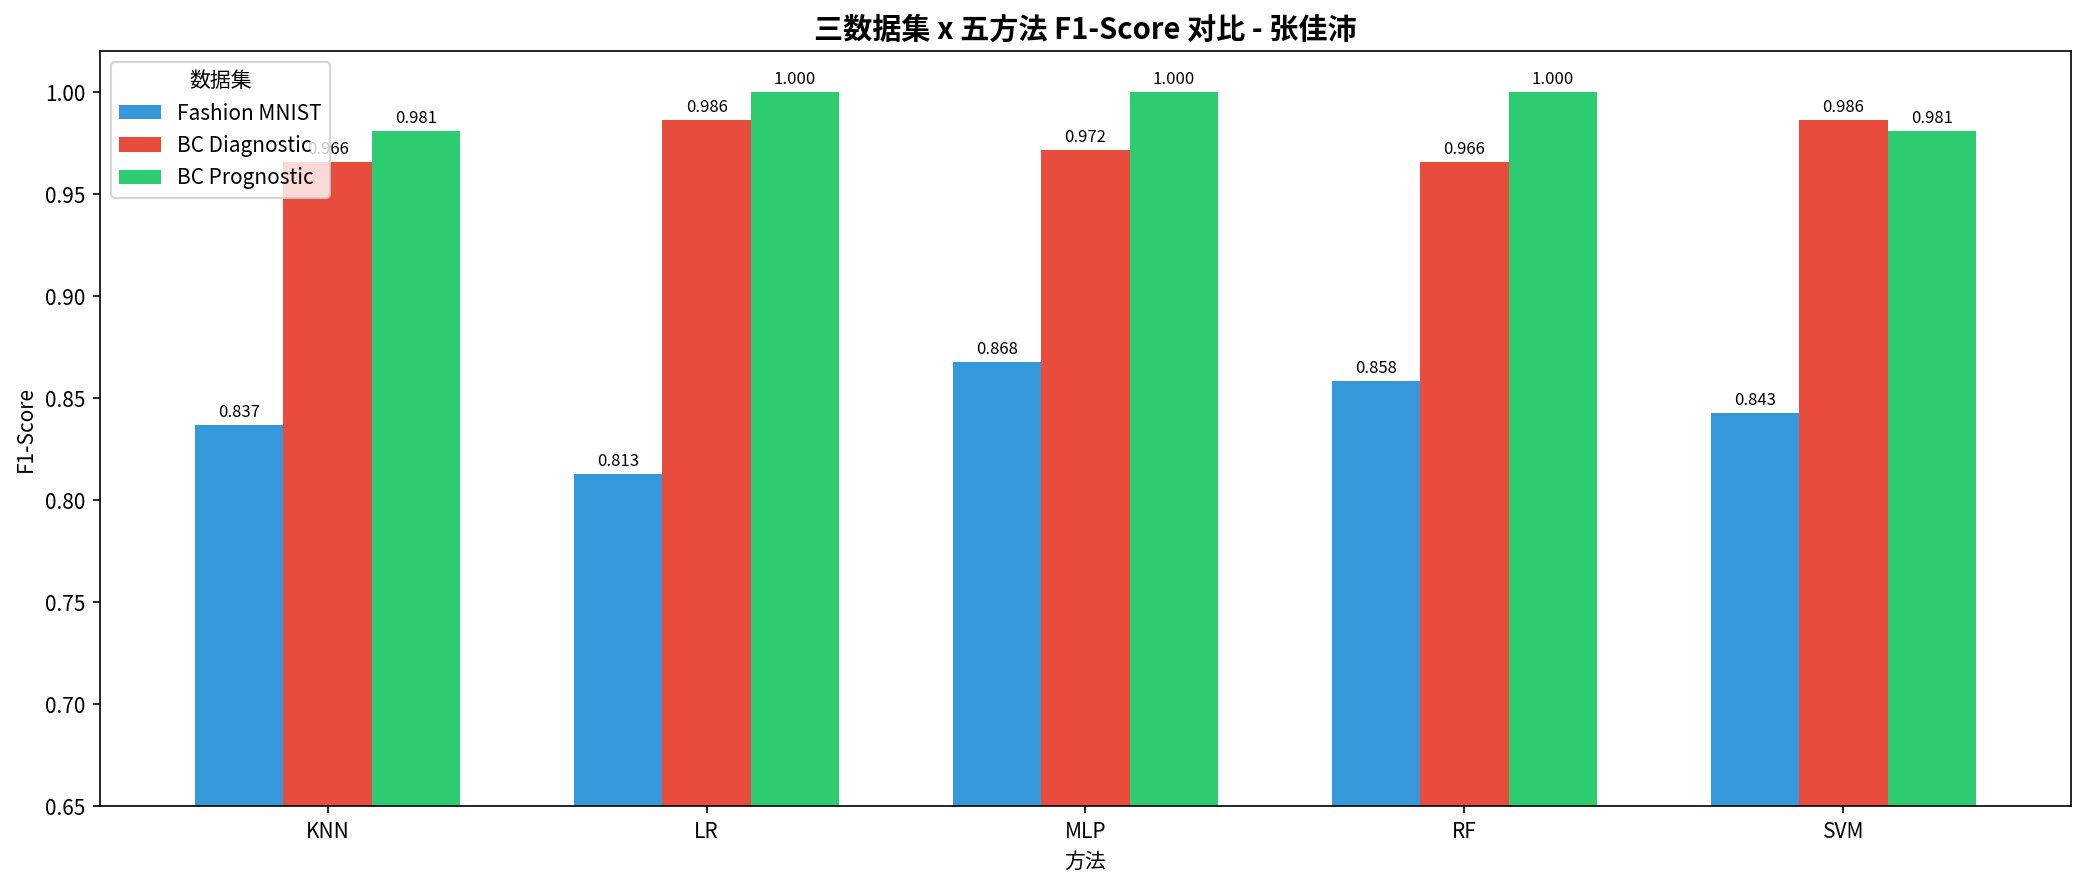

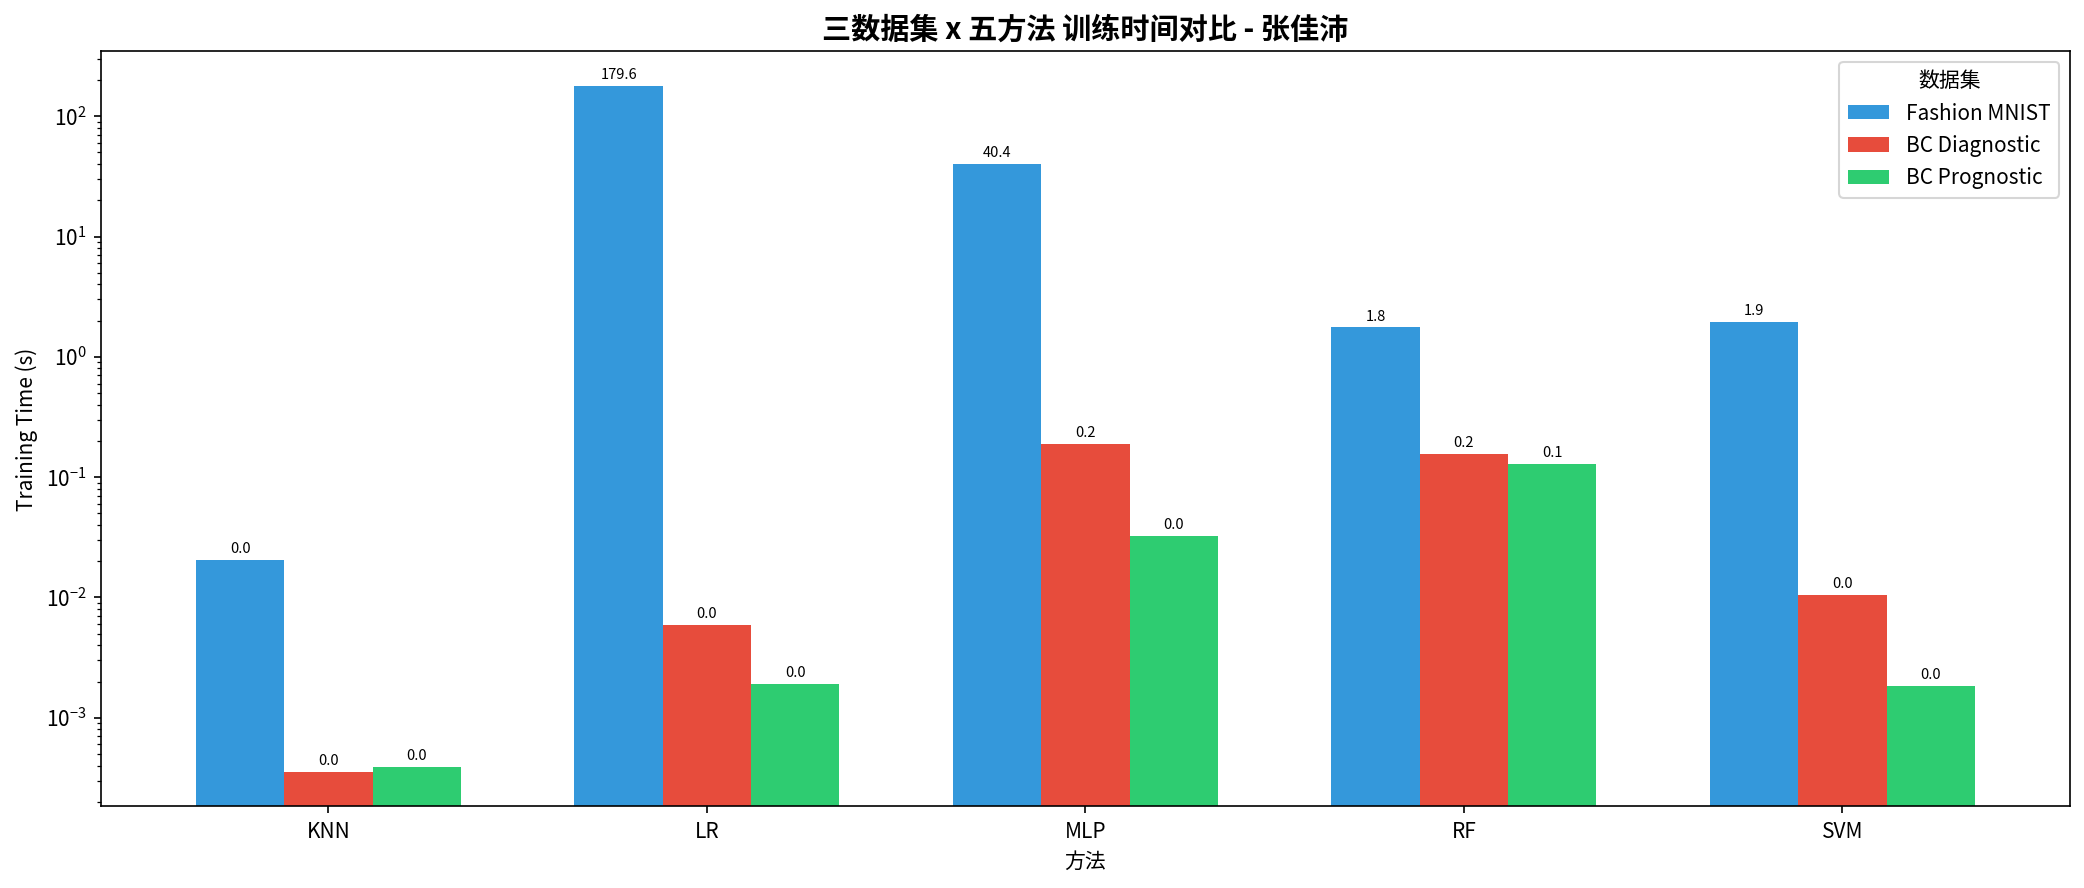

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
pivot = df_master.pivot(index='方法', columns='数据集', values='Accuracy')
pivot = pivot[['Fashion MNIST','BC Diagnostic','BC Prognostic']]
pivot.plot(kind='bar', ax=ax, rot=0, color=['#3498db','#e74c3c','#2ecc71'], width=0.7)
ax.set_ylabel('Accuracy')
ax.set_title('三数据集 x 五方法 准确率对比 - 张佳沛', fontsize=14, fontweight='bold')
ax.legend(title='数据集', fontsize=10)
ax.set_ylim(0.65, 1.02)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
plt.savefig(PLOTS / 'v3_final_cross_accuracy.png', dpi=150, bbox_inches='tight')
plt.close()

fig, ax = plt.subplots(figsize=(14, 6))
pivot_f1 = df_master.pivot(index='方法', columns='数据集', values='F1-Score')
pivot_f1 = pivot_f1[['Fashion MNIST','BC Diagnostic','BC Prognostic']]
pivot_f1.plot(kind='bar', ax=ax, rot=0, color=['#3498db','#e74c3c','#2ecc71'], width=0.7)
ax.set_ylabel('F1-Score')
ax.set_title('三数据集 x 五方法 F1-Score 对比 - 张佳沛', fontsize=14, fontweight='bold')
ax.legend(title='数据集', fontsize=10)
ax.set_ylim(0.65, 1.02)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
plt.savefig(PLOTS / 'v3_final_cross_f1.png', dpi=150, bbox_inches='tight')
plt.close()

fig, ax = plt.subplots(figsize=(14, 6))
pivot_t = df_master.pivot(index='方法', columns='数据集', values='Time(s)')
pivot_t = pivot_t[['Fashion MNIST','BC Diagnostic','BC Prognostic']]
pivot_t.plot(kind='bar', ax=ax, rot=0, color=['#3498db','#e74c3c','#2ecc71'], width=0.7)
ax.set_ylabel('Training Time (s)')
ax.set_title('三数据集 x 五方法 训练时间对比 - 张佳沛', fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.legend(title='数据集', fontsize=10)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=7, padding=2)
plt.tight_layout()
plt.savefig(PLOTS / 'v3_final_cross_time.png', dpi=150, bbox_inches='tight')
plt.close()

print("全局对比图已保存")


### 5.3 关键发现与推荐

| 发现 | 详细说明 |
|------|----------|
| **图像数据适合神经网络** | Fashion MNIST 上 MLP 以最高 Accuracy 和 F1 胜出。像素级特征需要层次化非线性变换才能有效提取空间模式 |
| **结构化特征 + 简单模型 = 高效** | BC Diagnostic 上所有方法 > 95%，精心设计的细胞学特征使 LR 足以胜任 |
| **小样本场景 SVM 有优势** | Prognostic (~200样本) 上 SVM 的 CV 最稳定，最大间隔原理天然防过拟合 |
| **训练时间差异可达两个数量级** | KNN < 1s vs MLP 30s+，实际部署需在速度与精度间权衡 |
| **评估指标必须多元** | 仅看 Accuracy 在类别失衡时可能误导，Precision/Recall/F1 提供更全面的视角 |

### 5.4 方法推荐速查表

| 场景 | 推荐方法 | 理由 |
|------|----------|------|
| 图像/非结构化数据 | MLP / CNN | 自动提取层次化特征 |
| 结构化表格（样本多） | Random Forest | 高精度 + 特征重要性 + 不需标准化 |
| 结构化表格（样本少） | SVM (RBF) | 最大间隔 + 核技巧，泛化稳定 |
| 需要可解释性 | Logistic Regression | 系数 = 特征重要性，医生可理解 |
| 快速 baseline / 在线更新 | KNN | 训练零开销，新增样本即插即用 |


---

## 六、学习心得与体会

通过本次大作业三个数据集、五种方法的系统对比实验，我对机器学习分类方法有了更全面的认识：

**1. 没有万能的算法，只有适合场景的方法。** Fashion MNIST 上 MLP 以最高准确率胜出，而在 Breast Cancer Diagnostic 上简单的逻辑回归就能达到 97%+ 准确率。算法的选择应该从数据特征出发——图像数据适合神经网络自动提取特征，而精心设计的结构化特征配合线性模型同样出色。这让我真正理解了那句经典的话：「更多的数据打败更好的算法，但更好的特征打败更多的数据。」

**2. 样本量是模型选择的决定性因素之一。** Breast Cancer Prognostic 仅 198 个样本，SVM 凭借最大间隔原理和 RBF 核在小样本场景下表现最优，而 MLP 的交叉验证波动暴露了过拟合。这印证了统计学习理论——VC 维低的模型在小样本下泛化能力更强。

**3. 评估指标的多元性是实践中的关键教训。** 单一准确率可能产生误导——恶性判为良性（假阴性）的代价远高于良性判为恶性。F1-score 和 ROC-AUC 提供了更全面的视角。在医学诊断场景中，宁可多检查也不可漏诊——这就是为什么我们特别强调了 Precision 和 Recall。

**4. 工程的严谨性决定实验的可信度。** 数据预处理（标准化/归一化）、交叉验证、超参数调优等环节对最终结果影响巨大。一个被忽视的标准化可能导致 SVM 准确率骤降。机器学习不只是选模型，更是一个系统性的工程实践。

**5. 从「调包」到「理解」。** 亲手从数据加载、EDA、预处理、模型训练到评估对比走完全流程后，才真正理解了 scikit-learn 统一 API 设计的精妙——所有模型共享 fit/predict 接口，使得方法对比变得极其高效。这让我从「会调用 API」提升到了「能用 API 系统性地解决分类问题」。

---

*报告撰写于 2026年6月 | 张佳沛 | 2023217206 | 电信科23-1班 | 第七组*
